# Analiza Clădire Instalații – ID_31 + ID_32
**Metode:** Detecție outlieri contextuală · IF · PELT · SAX · CDD & Heat Index · Logistic Regression · Senzor Virtual NILM · Carbon Intensity



In [1]:
import subprocess, sys
for pkg in ['ruptures', 'requests', 'scikit-learn', 'xgboost']:
    try:
        __import__(pkg.replace('-','_'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('Pachete OK.')


Pachete OK.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import requests
import warnings
import os
warnings.filterwarnings('ignore')
from collections import Counter
from scipy.stats import norm, pearsonr
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve,
                              mean_absolute_error, mean_squared_error, r2_score,
                              classification_report)
import ruptures as rpt

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

# ── Salvare automata grafice ──────────────────────────────────
SAVE_DIR = r'D:\Proiect IRA\Figuri_Articol'
os.makedirs(SAVE_DIR, exist_ok=True)
fig_counter = [0]
_original_show = plt.show

def auto_save_show(*args, **kwargs):
    fig_counter[0] += 1
    path = os.path.join(SAVE_DIR, f'fig_{fig_counter[0]:02d}.png')
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Salvat: fig_{fig_counter[0]:02d}.png')
    _original_show(*args, **kwargs)

plt.show = auto_save_show
print('Importuri OK.')
print(f'Graficele se salveaza automat in: {SAVE_DIR}')


Importuri OK.
Graficele se salveaza automat in: D:\Proiect IRA\Figuri_Articol


In [3]:
FILE_PATH = r'D:\Proiect IRA\Consum FTP Server 2017-2026 (2).xlsx'

df_raw = pd.read_excel(FILE_PATH, engine='openpyxl')
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw = df_raw.sort_values('Date').reset_index(drop=True)

df = df_raw[['Date', 'ID_31', 'ID_32']].copy()
df['ID_31'] = df['ID_31'].fillna(0).clip(lower=0)
df['ID_32'] = df['ID_32'].fillna(0).clip(lower=0)

print(f'Rânduri: {len(df):,}')
print(f'Interval: {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'ID_31 max={df["ID_31"].max():.2f} kW  mean={df["ID_31"].mean():.2f} kW')
print(f'ID_32 max={df["ID_32"].max():.2f} kW  mean={df["ID_32"].mean():.2f} kW')
df.head()

Rânduri: 239,447
Interval: 2017-12-02 → 2026-01-31
ID_31 max=149720.00 kW  mean=3.18 kW
ID_32 max=14390.00 kW  mean=0.36 kW


,Date,ID_31,ID_32
0,2017-12-02 00:06:54,6.312,0.041
1,2017-12-02 00:21:54,3.075,0.020
2,2017-12-02 00:36:54,3.254,0.020
3,2017-12-02 00:51:54,3.017,0.020
4,2017-12-02 01:06:54,3.125,0.020


---
##  Secțiunea 1.5 – Descărcare date meteo 

Temperatura exterioară este folosită ca validare contextuală pentru detecția outlierilor:
- Dacă ID_32 > 2 kW și temperatura afară > 15°C → chiller real 
- Dacă ID_32 > 2 kW și temperatura afară < 15°C → suspect: fie senzor blocat, fie zgomot de contor



In [4]:
print('Descarcare date meteo Cluj-Napoca (temperatura + umiditate) de la Open-Meteo...')

start_date = df['Date'].min().strftime('%Y-%m-%d')
end_date   = df['Date'].max().strftime('%Y-%m-%d')

url = (
    'https://archive-api.open-meteo.com/v1/archive'
    '?latitude=46.7712&longitude=23.6236'
    f'&start_date={start_date}&end_date={end_date}'
    '&hourly=temperature_2m,relative_humidity_2m'
    '&timezone=Europe%2FBucharest'
)

try:
    response = requests.get(url, timeout=30)
    data_meteo = response.json()
    df_meteo = pd.DataFrame({
        'Date':     pd.to_datetime(data_meteo['hourly']['time']),
        'temp_C':   data_meteo['hourly']['temperature_2m'],
        'humidity': data_meteo['hourly']['relative_humidity_2m']
    })
    df_meteo_15 = df_meteo.set_index('Date').resample('15min').interpolate(method='time').reset_index()
    df = df.sort_values('Date')
    df = pd.merge_asof(df, df_meteo_15, on='Date',
                       tolerance=pd.Timedelta('30min'), direction='nearest')
    METEO_OK = df['temp_C'].notna().sum() > len(df) * 0.9
    print(f'Date meteo descarcate: {len(df_meteo):,} ore')
    print(f'Interval: {df_meteo["Date"].min().date()} -> {df_meteo["Date"].max().date()}')
    print(f'Temperatura: min={df_meteo["temp_C"].min():.1f}C  max={df_meteo["temp_C"].max():.1f}C')
    print(f'Umiditate:   min={df_meteo["humidity"].min():.0f}%  max={df_meteo["humidity"].max():.0f}%')
    print(f'Merge OK: {df["temp_C"].notna().sum():,} randuri cu date meteo')
except Exception as e:
    print(f'Eroare descarcare meteo: {e}')
    temp_medie_lunara  = {1:-2,2:0,3:6,4:12,5:17,6:20,7:22,8:22,9:17,10:11,11:5,12:0}
    humid_medie_lunara = {1:75,2:70,3:60,4:55,5:55,6:55,7:50,8:50,9:60,10:70,11:75,12:78}
    df['temp_C']   = df['Date'].dt.month.map(temp_medie_lunara).astype(float)
    df['humidity'] = df['Date'].dt.month.map(humid_medie_lunara).astype(float)
    METEO_OK = False
    print('Se folosesc medii climatologice lunare ca fallback.')

print(f'METEO_OK = {METEO_OK}')


Descarcare date meteo Cluj-Napoca (temperatura + umiditate) de la Open-Meteo...
Date meteo descarcate: 71,592 ore
Interval: 2017-12-02 -> 2026-01-31
Temperatura: min=-16.7C  max=36.1C
Umiditate:   min=10%  max=100%
Merge OK: 239,445 randuri cu date meteo
METEO_OK = True


---
##  Secțiunea 2 – Detecție outlieri contextuală + Curățare


Problemele identificate în datele ID_32:
1. valori >50 kW (ex: 14390 kW, 916 kW) = erori clare de contor
2. senzor blocat- aceeași valoare exactă repetată z consecutiv (ex: 2.027 kW )
3.  valori >2 kW când afară e sub 15°C sunt susepecte; un chiller de răcire nu are motiv fizic să pornească pe frig


 NU folosim isolation forest deoarece chillerul e activ doar ~5-34% din lunile de vară → IF tratează funcționarea normală ca "anomalie rara" → marchează gresit valorile de 4-6 kW (chiller pornit) ca outlieri, deci vara apare incorect ca inactivă.

In [5]:
# ── Parametri detecție ────────────────────────────────────────
PHYS_LIMIT_32    = 50.0   # kW — limita fizică maximă a chillerului
PHYS_LIMIT_31    = 500.0  # kW — limita fizică a consumului general al clădirii
FROZEN_MIN_RUN   = 8      # nr. minim de valori identice consecutive = senzor blocat
FROZEN_MIN_VAL   = 1.5    # kW — valoarea minimă pentru a considera un run ca frozen
TEMP_MIN_CHILLER = 15.0   # °C — sub această temperatură, chillerul nu ar trebui să pornească
THRESHOLD_ON     = 2.0    # kW — threshold ON/OFF chiller (gap natural în distribuție)
CONTAMINATION_IF = 0.01   # pentru Isolation Forest pe ID_31

print('Parametri setați:')
print(f'  Limită fizică ID_32:   {PHYS_LIMIT_32} kW')
print(f'  Limită fizică ID_31:   {PHYS_LIMIT_31} kW')
print(f'  Frozen sensor run min: {FROZEN_MIN_RUN} valori identice consecutive')
print(f'  Temp. minimă chiller:  {TEMP_MIN_CHILLER}°C')
print(f'  Threshold ON/OFF:      {THRESHOLD_ON} kW')

Parametri setați:
  Limită fizică ID_32:   50.0 kW
  Limită fizică ID_31:   500.0 kW
  Frozen sensor run min: 8 valori identice consecutive
  Temp. minimă chiller:  15.0°C
  Threshold ON/OFF:      2.0 kW


In [6]:
# ── Etapa 1: Outlieri fizic imposibili ───────────────────────
mask_phys_32 = df['ID_32'] > PHYS_LIMIT_32
mask_phys_31 = df['ID_31'] > PHYS_LIMIT_31

print(f'Outlieri fizici ID_32 (>{PHYS_LIMIT_32} kW): {mask_phys_32.sum()}')
print(df.loc[mask_phys_32, ['Date', 'ID_32']].to_string())
print()
print(f'Outlieri fizici ID_31 (>{PHYS_LIMIT_31} kW): {mask_phys_31.sum()}')
print(df.loc[mask_phys_31, ['Date', 'ID_31']].to_string())

Outlieri fizici ID_32 (>50.0 kW): 6
                      Date      ID_32
1807   2017-12-21 08:07:41     51.123
2389   2017-12-27 09:37:41    205.314
4368   2018-01-22 16:16:42    916.491
9542   2018-03-22 17:38:48    306.888
104912 2022-02-21 10:02:29  14390.000
153643 2023-07-28 13:03:29     97.164

Outlieri fizici ID_31 (>500.0 kW): 6
                      Date       ID_31
1807   2017-12-21 08:07:41     707.532
2389   2017-12-27 09:37:41    1583.500
4368   2018-01-22 16:16:42    9967.500
9542   2018-03-22 17:38:48    2558.100
104912 2022-02-21 10:02:29  149720.000
153643 2023-07-28 13:03:29     711.721


In [7]:
# ── Etapa 2: Detecție senzor blocat (frozen sensor) ──────────
# Un senzor blocat produce aceeași valoare exactă repetată ore/zile întregi
# Exemplu real: 2.027 kW repetat neîntrerupt din 27 dec 2017 → 4 ian 2018
# Diferență față de chiller real: un chiller fluctuează natural cu ±0.5-2 kW

def detecteaza_frozen_sensor(series, min_run=8, min_val=1.5):
    """
    Detectează run-uri de valori identice consecutive care indică un senzor blocat.
    Exclude lunile de vară (iun-aug) unde un run lung poate fi chiller real la sarcină constantă.
    """
    # Grupăm valorile consecutive identice
    groups    = (series != series.shift()).cumsum()
    run_sizes = series.groupby(groups).transform('count')
    run_vals  = series.groupby(groups).transform('first')
    # Condiție frozen: run lung + valoare în zona suspectă
    frozen = (run_sizes >= min_run) & (run_vals >= min_val)
    return frozen

mask_frozen_all = detecteaza_frozen_sensor(df['ID_32'], FROZEN_MIN_RUN, FROZEN_MIN_VAL)

# Excepție: vara (iun-aug) un run lung poate fi chiller real la sarcină constantă
# Exemplu: 5.929 kW repetat 4-11 iulie 2022 — chiller blocat la sarcină, dar real
# Îl păstrăm deoarece temperatura exterioară > 20°C justifică funcționarea
luna_df = df['Date'].dt.month
mask_frozen_32 = mask_frozen_all & luna_df.isin([10, 11, 12, 1, 2, 3, 4, 5])

print(f'Frozen sensor detectat (excluzând vara): {mask_frozen_32.sum():,} înregistrări')
print()
print('Valori unice frozen și perioadele lor:')
frozen_df = df[mask_frozen_32].copy()
for val in sorted(frozen_df['ID_32'].unique()):
    sub = frozen_df[frozen_df['ID_32'] == val]
    print(f'  {val:.3f} kW → {sub["Date"].min().date()} – {sub["Date"].max().date()}  ({len(sub)} înregistrări)')

Frozen sensor detectat (excluzând vara): 1,230 înregistrări

Valori unice frozen și perioadele lor:
  1.881 kW → 2017-12-22 – 2017-12-27  (471 înregistrări)
  2.027 kW → 2017-12-27 – 2018-01-04  (759 înregistrări)


In [8]:
# ── Etapa 3: Validare cu temperatura exterioară ───────────────
# Valori >2 kW când temperatura afară < TEMP_MIN_CHILLER sunt suspecte
# Dacă nu sunt deja marcate ca frozen/fizic, le marcăm ca outlieri contextuali

mask_deja_eliminat = mask_phys_32 | mask_frozen_32

# Outlieri contextuali: ID_32 > threshold ON, temp < min, nu sunt deja eliminați
mask_context_32 = (
    (df['ID_32'] > THRESHOLD_ON) &
    (df['temp_C'] < TEMP_MIN_CHILLER) &
    (~mask_deja_eliminat)
)

print(f'Outlieri contextuali (>2kW când temp<{TEMP_MIN_CHILLER}°C, nefrozen): {mask_context_32.sum():,}')
if mask_context_32.sum() > 0:
    ctx = df[mask_context_32][['Date', 'ID_32', 'temp_C']]
    print('Primele 20:')
    print(ctx.head(20).to_string())
    print()
    print('Distribuție lunară a outlierilor contextuali:')
    print(ctx['Date'].dt.month.value_counts().sort_index())

print()
print('=== SUMAR OUTLIERI ID_32 ===')
print(f'  Fizici (>{PHYS_LIMIT_32}kW):          {mask_phys_32.sum():>6}')
print(f'  Frozen sensor:                 {mask_frozen_32.sum():>6}')
print(f'  Contextuali (frig+consum):     {mask_context_32.sum():>6}')
mask_all_bad_32 = mask_phys_32 | mask_frozen_32 | mask_context_32
print(f'  TOTAL eliminat:                {mask_all_bad_32.sum():>6} ({100*mask_all_bad_32.sum()/len(df):.2f}%)')
print()
print(f'  Rămân valori >2kW (chiller real): {((~mask_all_bad_32) & (df["ID_32"]>THRESHOLD_ON)).sum():>6}')

Outlieri contextuali (>2kW când temp<15.0°C, nefrozen): 513
Primele 20:
                    Date   ID_32  temp_C
126  2017-12-03 07:36:54   2.058   0.950
216  2017-12-04 06:06:54   2.051  -0.200
223  2017-12-04 07:51:54   2.067  -0.700
230  2017-12-04 09:36:54   2.105  -1.000
650  2017-12-08 18:36:54   2.045   4.150
655  2017-12-08 19:51:54   2.094   3.900
710  2017-12-09 09:36:54   2.051   1.950
991  2017-12-12 19:11:20   2.100   8.350
1180 2017-12-14 18:26:20   2.099   4.900
1273 2017-12-15 17:41:20   2.043   7.275
1526 2017-12-18 09:52:41   2.086  -0.600
1607 2017-12-19 06:07:41   2.066  -3.200
1608 2017-12-19 06:22:41   2.066  -3.200
1609 2017-12-19 06:37:41   2.055  -3.200
1617 2017-12-19 08:37:41   2.086  -3.350
1900 2017-12-22 07:22:41  10.714  -2.750
2404 2017-12-27 13:22:41   9.052   7.500
4502 2018-01-24 05:47:33   2.346  -5.500
4615 2018-01-25 12:59:14   2.353   1.400
4677 2018-01-26 06:13:04   2.299  -3.775

Distribuție lunară a outlierilor contextuali:
Date
1     74
2     

Salvat: fig_01.png


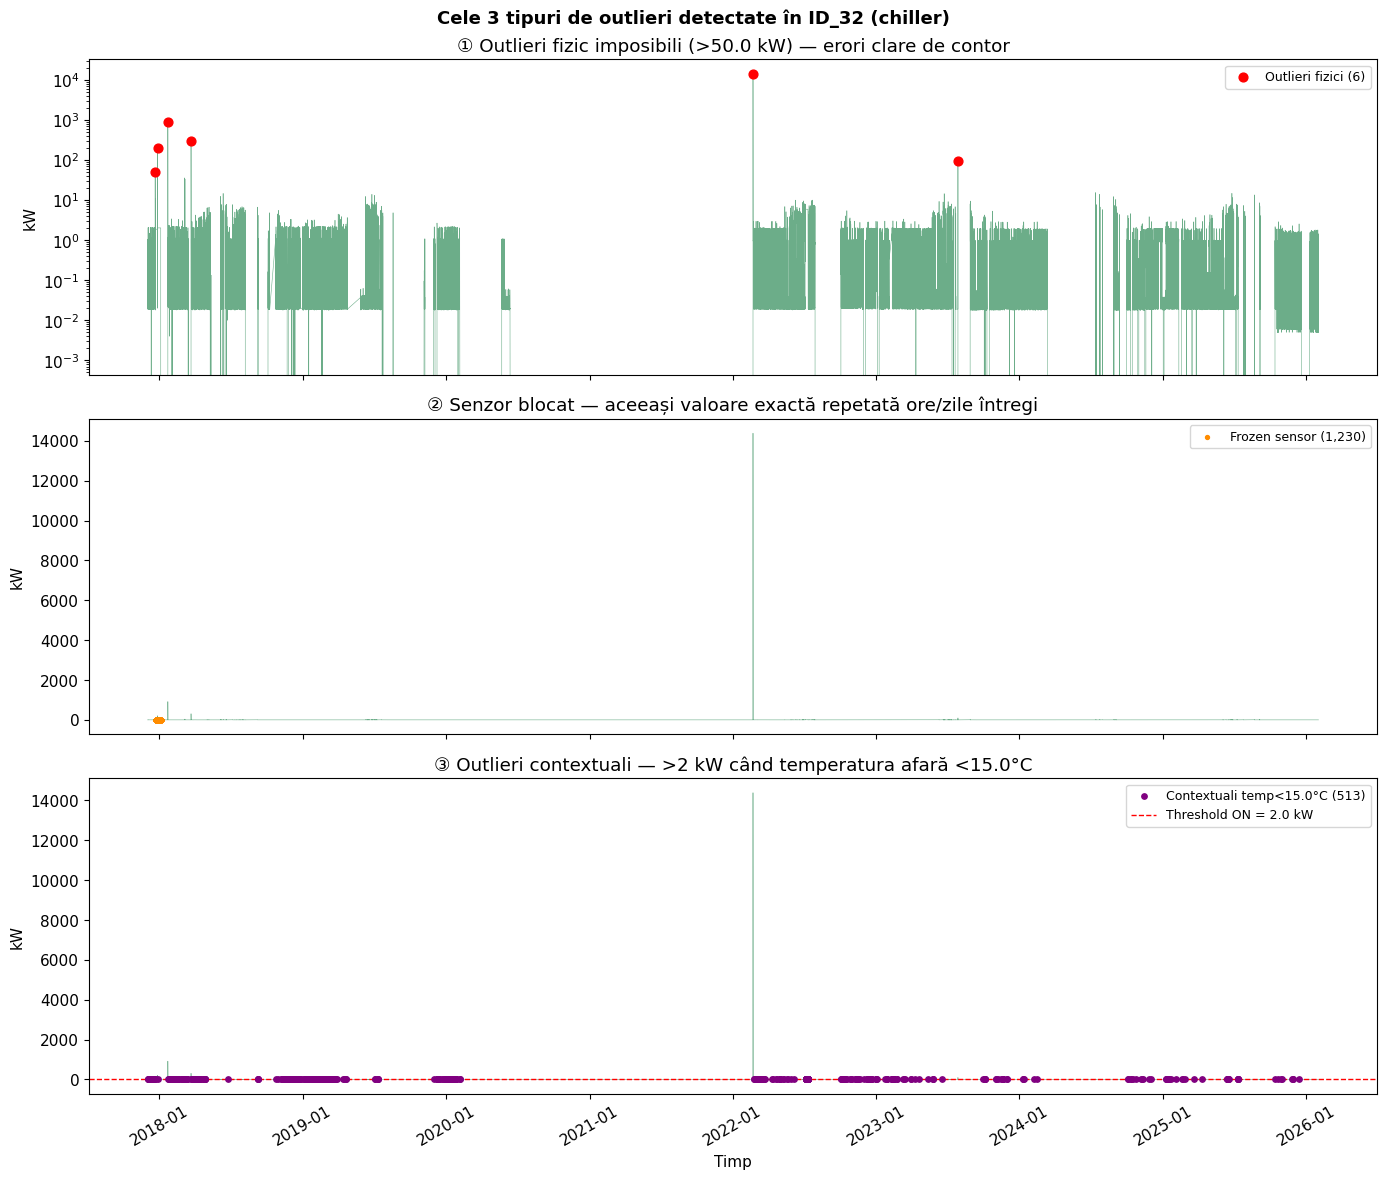

In [9]:
# ── Grafic: cele 3 tipuri de outlieri vizualizate ─────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: outlieri fizici
axes[0].plot(df['Date'], df['ID_32'], color='seagreen', linewidth=0.4, alpha=0.7)
axes[0].scatter(df.loc[mask_phys_32, 'Date'], df.loc[mask_phys_32, 'ID_32'],
                color='red', s=40, zorder=5, label=f'Outlieri fizici ({mask_phys_32.sum()})')
axes[0].set_ylabel('kW')
axes[0].set_title(f'① Outlieri fizic imposibili (>{PHYS_LIMIT_32} kW) — erori clare de contor')
axes[0].legend(fontsize=9)
axes[0].set_yscale('log')

# Panel 2: frozen sensor
axes[1].plot(df['Date'], df['ID_32'], color='seagreen', linewidth=0.4, alpha=0.7)
axes[1].scatter(df.loc[mask_frozen_32, 'Date'], df.loc[mask_frozen_32, 'ID_32'],
                color='darkorange', s=8, zorder=5, label=f'Frozen sensor ({mask_frozen_32.sum():,})')
axes[1].set_ylabel('kW')
axes[1].set_title('② Senzor blocat — aceeași valoare exactă repetată ore/zile întregi')
axes[1].legend(fontsize=9)

# Panel 3: contextuali
axes[2].plot(df['Date'], df['ID_32'], color='seagreen', linewidth=0.4, alpha=0.7)
if mask_context_32.sum() > 0:
    axes[2].scatter(df.loc[mask_context_32, 'Date'], df.loc[mask_context_32, 'ID_32'],
                    color='purple', s=15, zorder=5,
                    label=f'Contextuali temp<{TEMP_MIN_CHILLER}°C ({mask_context_32.sum():,})')
axes[2].axhline(THRESHOLD_ON, color='red', linestyle='--', linewidth=1,
                label=f'Threshold ON = {THRESHOLD_ON} kW')
axes[2].set_ylabel('kW')
axes[2].set_xlabel('Timp')
axes[2].set_title(f'③ Outlieri contextuali — >2 kW când temperatura afară <{TEMP_MIN_CHILLER}°C')
axes[2].legend(fontsize=9)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30)

plt.suptitle('Cele 3 tipuri de outlieri detectate în ID_32 (chiller)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# ── Curățare + interpolare ────────────────────────────────────
cols_meteo = ['Date','ID_31','ID_32','temp_C']
if 'humidity' in df.columns:
    cols_meteo.append('humidity')
df_clean = df[cols_meteo].copy()
if 'humidity' not in df_clean.columns:
    humid_medie_lunara = {1:75,2:70,3:60,4:55,5:55,6:55,7:50,8:50,9:60,10:70,11:75,12:78}
    df_clean['humidity'] = df_clean['Date'].dt.month.map(humid_medie_lunara).astype(float)

# Eliminăm toți outlier-ii identificați
df_clean.loc[mask_all_bad_32, 'ID_32'] = np.nan
df_clean.loc[mask_phys_31,    'ID_31'] = np.nan

# Interpolare liniară pentru valorile eliminate
df_clean['ID_32'] = df_clean['ID_32'].interpolate(method='linear').clip(lower=0)
df_clean['ID_31'] = df_clean['ID_31'].interpolate(method='linear').clip(lower=0)

# Etichetare ON/OFF chiller
df_clean['ID_32_ON'] = (df_clean['ID_32'] > THRESHOLD_ON).astype(int)
df_clean['YM']       = df_clean['Date'].dt.to_period('M')

def get_anotimp(m):
    if m in [12, 1, 2]:  return 'Iarnă'
    elif m in [3, 4, 5]: return 'Primăvară'
    elif m in [6, 7, 8]: return 'Vară'
    else:                 return 'Toamnă'

df_clean['Anotimp'] = df_clean['Date'].dt.month.map(get_anotimp)
order_sez = ['Iarnă', 'Primăvară', 'Vară', 'Toamnă']

print(f'Threshold ON/OFF: {THRESHOLD_ON} kW')
print(f'Chiller activ total: {100*df_clean["ID_32_ON"].mean():.1f}%')
print()
print('Activitate per anotimp (vara trebuie să fie cea mai activă):')
for s in order_sez:
    pct = 100 * df_clean.loc[df_clean['Anotimp']==s, 'ID_32_ON'].mean()
    med = df_clean.loc[df_clean['Anotimp']==s, 'ID_32'].median()
    mx  = df_clean.loc[df_clean['Anotimp']==s, 'ID_32'].max()
    print(f'  {s:<12}: activ {pct:.1f}%  median={med:.3f} kW  max={mx:.2f} kW')

Threshold ON/OFF: 2.0 kW
Chiller activ total: 1.6%

Activitate per anotimp (vara trebuie să fie cea mai activă):
  Iarnă       : activ 0.0%  median=0.020 kW  max=2.00 kW
  Primăvară   : activ 0.6%  median=0.019 kW  max=7.16 kW
  Vară        : activ 5.4%  median=0.000 kW  max=15.48 kW
  Toamnă      : activ 0.4%  median=0.019 kW  max=10.42 kW


In [11]:
# ── Isolation Forest doar pe ID_31 ───────────────────────────
df_clean['ID_31_delta'] = df_clean['ID_31'].diff().fillna(0)
X_31 = StandardScaler().fit_transform(df_clean[['ID_31', 'ID_31_delta']].values)
iso_31 = IsolationForest(contamination=CONTAMINATION_IF, random_state=42, n_estimators=100)
df_clean['IF_31']       = iso_31.fit_predict(X_31)
df_clean['IF_31_score'] = iso_31.score_samples(X_31)
mask_out_31 = df_clean['IF_31'] == -1

df_clean.loc[mask_out_31, 'ID_31'] = np.nan
df_clean['ID_31'] = df_clean['ID_31'].interpolate(method='linear').clip(lower=0)

print(f'IF outlieri ID_31: {mask_out_31.sum():,} ({100*mask_out_31.sum()/len(df_clean):.2f}%)')

IF outlieri ID_31: 2,394 (1.00%)


Salvat: fig_02.png


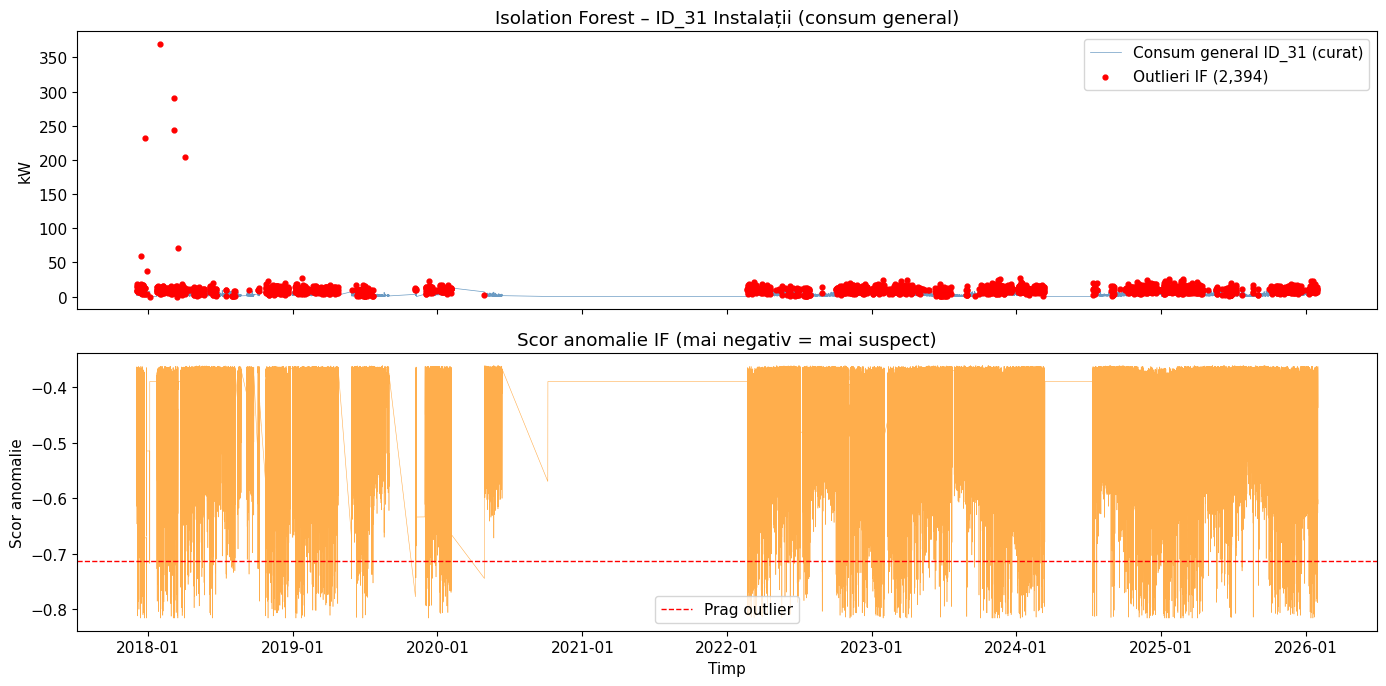

In [12]:
# ── Grafic IF ID_31 ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax1.plot(df_clean['Date'], df_clean['ID_31'], color='steelblue', linewidth=0.5, alpha=0.8,
         label='Consum general ID_31 (curat)')
ax1.scatter(df.loc[mask_out_31, 'Date'], df.loc[mask_out_31, 'ID_31'],
            color='red', s=12, zorder=5, label=f'Outlieri IF ({mask_out_31.sum():,})')
ax1.set_ylabel('kW')
ax1.set_title('Isolation Forest – ID_31 Instalații (consum general)')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
prag_31 = df_clean.loc[mask_out_31, 'IF_31_score'].max() if mask_out_31.sum() > 0 else -0.5
ax2.plot(df_clean['Date'], df_clean['IF_31_score'], color='darkorange', linewidth=0.4, alpha=0.7)
ax2.axhline(prag_31, color='red', linestyle='--', linewidth=1, label='Prag outlier')
ax2.set_ylabel('Scor anomalie')
ax2.set_xlabel('Timp')
ax2.set_title('Scor anomalie IF (mai negativ = mai suspect)')
ax2.legend()
plt.tight_layout()
plt.show()

Salvat: fig_03.png


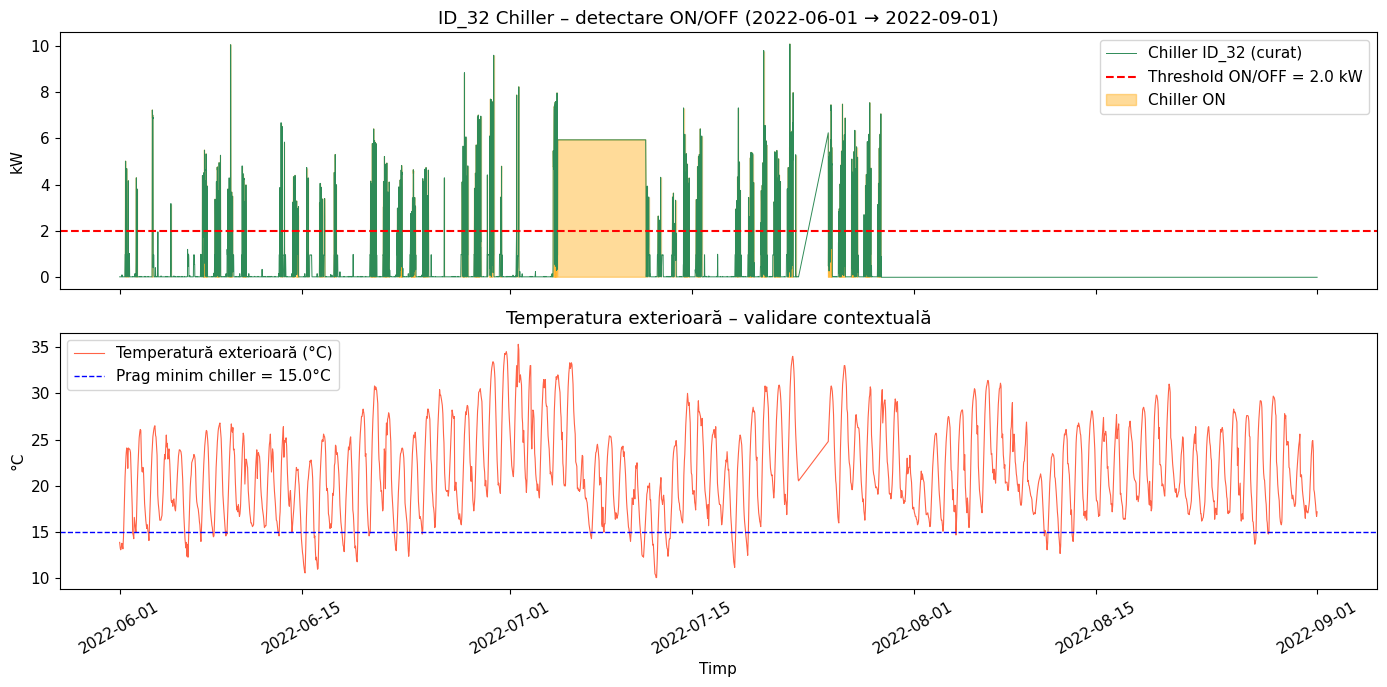

In [13]:
# ── Grafic chiller curat cu threshold vizualizat ──────────────
best_month = df_clean.groupby('YM')['ID_32'].mean().idxmax()
ZOOM_START_CL = (best_month - 1).to_timestamp().strftime('%Y-%m-%d')
ZOOM_END_CL   = (best_month + 2).to_timestamp().strftime('%Y-%m-%d')
mz = (df_clean['Date'] >= ZOOM_START_CL) & (df_clean['Date'] <= ZOOM_END_CL)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(df_clean.loc[mz, 'Date'], df_clean.loc[mz, 'ID_32'],
         color='seagreen', linewidth=0.7, label='Chiller ID_32 (curat)')
ax1.axhline(THRESHOLD_ON, color='red', linestyle='--', linewidth=1.5,
            label=f'Threshold ON/OFF = {THRESHOLD_ON} kW')
ax1.fill_between(df_clean.loc[mz, 'Date'], 0, df_clean.loc[mz, 'ID_32'],
                 where=df_clean.loc[mz, 'ID_32_ON'].values.astype(bool),
                 color='orange', alpha=0.4, label='Chiller ON')
ax1.set_ylabel('kW')
ax1.set_title(f'ID_32 Chiller – detectare ON/OFF ({ZOOM_START_CL} → {ZOOM_END_CL})')
ax1.legend()

ax2.plot(df_clean.loc[mz, 'Date'], df_clean.loc[mz, 'temp_C'],
         color='tomato', linewidth=0.8, label='Temperatură exterioară (°C)')
ax2.axhline(TEMP_MIN_CHILLER, color='blue', linestyle='--', linewidth=1,
            label=f'Prag minim chiller = {TEMP_MIN_CHILLER}°C')
ax2.set_ylabel('°C')
ax2.set_xlabel('Timp')
ax2.set_title('Temperatura exterioară – validare contextuală')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)
plt.tight_layout()
plt.show()

---
## Secțiunea 3 – Comparație IQR vs Isolation Forest (pe ID_31)

In [14]:
s31 = df['ID_31']
q1, q3 = s31.quantile(0.25), s31.quantile(0.75)
iqr = q3 - q1
low_iqr = q1 - 1.5 * iqr
up_iqr  = q3 + 1.5 * iqr
mask_iqr_31 = (s31 < low_iqr) | (s31 > up_iqr)

fals_pozitive_iqr = mask_iqr_31 & ~mask_out_31
acord             = mask_iqr_31 & mask_out_31
doar_if           = ~mask_iqr_31 & mask_out_31

print('=== Comparație IQR vs Isolation Forest pe ID_31 ===')
print(f'Limită IQR inferioară: {low_iqr:.3f} kW')
print(f'Limită IQR superioară: {up_iqr:.3f} kW')
print()
print(f'Outlieri IQR:                {mask_iqr_31.sum():>8,}  ({100*mask_iqr_31.sum()/len(df):.2f}%)')
print(f'Outlieri IF:                 {mask_out_31.sum():>8,}  ({100*mask_out_31.sum()/len(df):.2f}%)')
print(f'Fals pozitive IQR:           {fals_pozitive_iqr.sum():>8,}')
print(f'Detectate de ambele:         {acord.sum():>8,}')
print(f'Detectate doar de IF:        {doar_if.sum():>8,}')
if mask_iqr_31.sum() > 0:
    print(f'Reducere fals pozitive IF:   {100*(mask_iqr_31.sum()-mask_out_31.sum())/mask_iqr_31.sum():.1f}%')

=== Comparație IQR vs Isolation Forest pe ID_31 ===
Limită IQR inferioară: -3.302 kW
Limită IQR superioară: 7.934 kW

Outlieri IQR:                   4,915  (2.05%)
Outlieri IF:                    2,394  (1.00%)
Fals pozitive IQR:              3,264
Detectate de ambele:            1,651
Detectate doar de IF:             743
Reducere fals pozitive IF:   51.3%


Salvat: fig_04.png


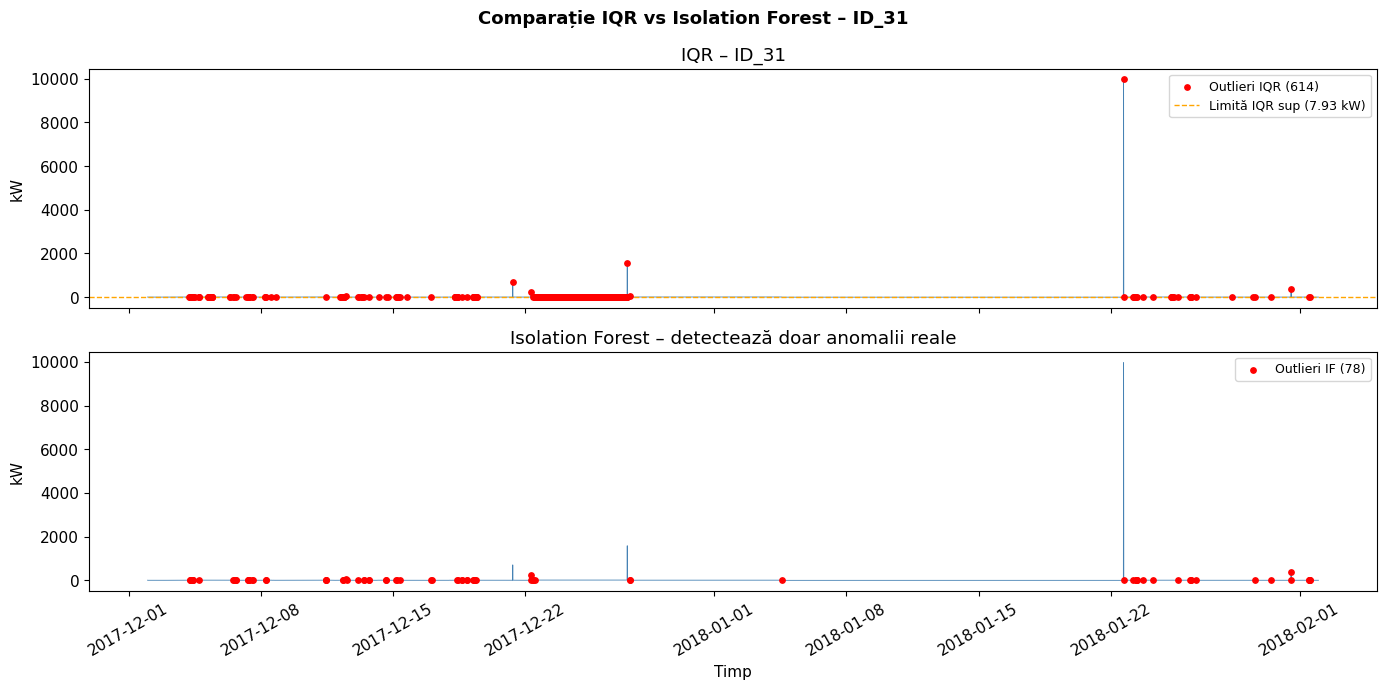

In [15]:
out_dates = df.loc[mask_out_31, 'Date']
first_out = out_dates.iloc[0] if len(out_dates) > 0 else pd.Timestamp('2019-01-01')
ZS = (first_out - pd.Timedelta(days=30)).strftime('%Y-%m-%d')
ZE = (first_out + pd.Timedelta(days=60)).strftime('%Y-%m-%d')
mz_c = (df['Date'] >= ZS) & (df['Date'] <= ZE)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax1.plot(df.loc[mz_c, 'Date'], df.loc[mz_c, 'ID_31'], color='steelblue', linewidth=0.6)
ax1.scatter(df.loc[mz_c & mask_iqr_31, 'Date'], df.loc[mz_c & mask_iqr_31, 'ID_31'],
            color='red', s=15, zorder=5, label=f'Outlieri IQR ({mask_iqr_31[mz_c].sum():,})')
ax1.axhline(up_iqr, color='orange', linestyle='--', linewidth=1, label=f'Limită IQR sup ({up_iqr:.2f} kW)')
ax1.set_ylabel('kW')
ax1.set_title('IQR – ID_31')
ax1.legend(fontsize=9)

ax2.plot(df.loc[mz_c, 'Date'], df.loc[mz_c, 'ID_31'], color='steelblue', linewidth=0.6)
ax2.scatter(df.loc[mz_c & mask_out_31, 'Date'], df.loc[mz_c & mask_out_31, 'ID_31'],
            color='red', s=15, zorder=5, label=f'Outlieri IF ({mask_out_31[mz_c].sum():,})')
ax2.set_ylabel('kW')
ax2.set_xlabel('Timp')
ax2.set_title('Isolation Forest – detectează doar anomalii reale')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)
plt.suptitle('Comparație IQR vs Isolation Forest – ID_31', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Salvat: fig_05.png


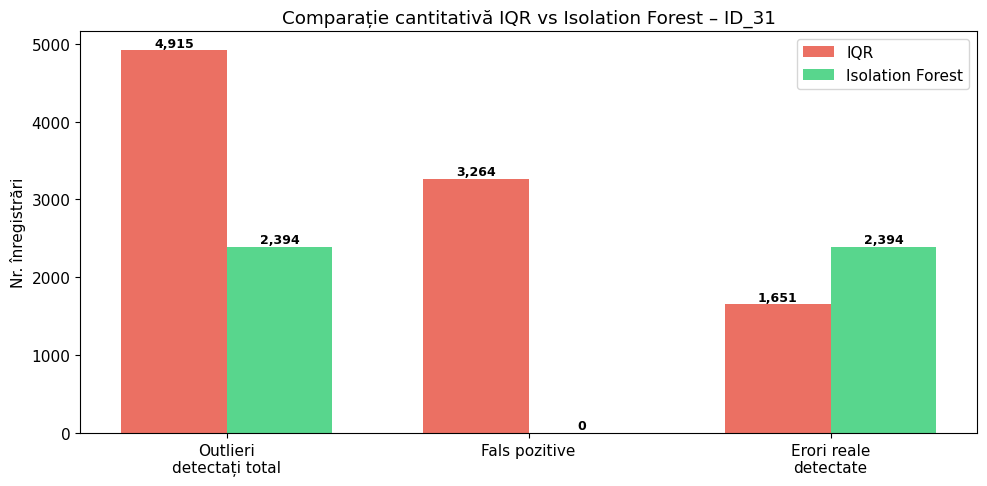

In [16]:
categorii = ['Outlieri\ndetectați total', 'Fals pozitive', 'Erori reale\ndetectate']
valori_iqr = [mask_iqr_31.sum(), fals_pozitive_iqr.sum(), acord.sum()]
valori_if  = [mask_out_31.sum(), 0, mask_out_31.sum()]
x = np.arange(len(categorii))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, valori_iqr, width, label='IQR', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, valori_if,  width, label='Isolation Forest', color='#2ecc71', alpha=0.8)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{int(bar.get_height()):,}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{int(bar.get_height()):,}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Nr. înregistrări')
ax.set_title('Comparație cantitativă IQR vs Isolation Forest – ID_31')
ax.set_xticks(x)
ax.set_xticklabels(categorii)
ax.legend()
plt.tight_layout()
plt.show()

---
##  Secțiunea 4 – Change Point Detection (PELT)

In [17]:
PELT_PENALTY = 10

best_month = df_clean.groupby('YM')['ID_32'].mean().idxmax()
ZOOM_START_CP = (best_month - 2).to_timestamp().strftime('%Y-%m-%d')
ZOOM_END_CP   = (best_month + 2).to_timestamp().strftime('%Y-%m-%d')
print(f'Perioadă PELT: {ZOOM_START_CP} → {ZOOM_END_CP}')

mz_cp        = (df_clean['Date'] >= ZOOM_START_CP) & (df_clean['Date'] <= ZOOM_END_CP)
signal_cp    = df_clean.loc[mz_cp, 'ID_32'].values
dates_cp     = df_clean.loc[mz_cp, 'Date'].values
signal_gen_z = df_clean.loc[mz_cp, 'ID_31'].values

signal_cp_ds  = signal_cp[::4]
dates_cp_ds   = dates_cp[::4]
signal_gen_ds = signal_gen_z[::4]

algo = rpt.Pelt(model='rbf').fit(signal_cp_ds)
breakpoints = [b for b in algo.predict(pen=PELT_PENALTY) if b < len(signal_cp_ds)]
print(f'Change points detectate: {len(breakpoints)}')
for bp in breakpoints[:10]:
    print(f'  → {pd.Timestamp(dates_cp_ds[bp]).strftime("%Y-%m-%d %H:%M")}')

Perioadă PELT: 2022-05-01 → 2022-09-01
Change points detectate: 4
  → 2022-05-12 06:48
  → 2022-07-04 15:57
  → 2022-07-11 13:16
  → 2022-07-29 11:17


Salvat: fig_06.png


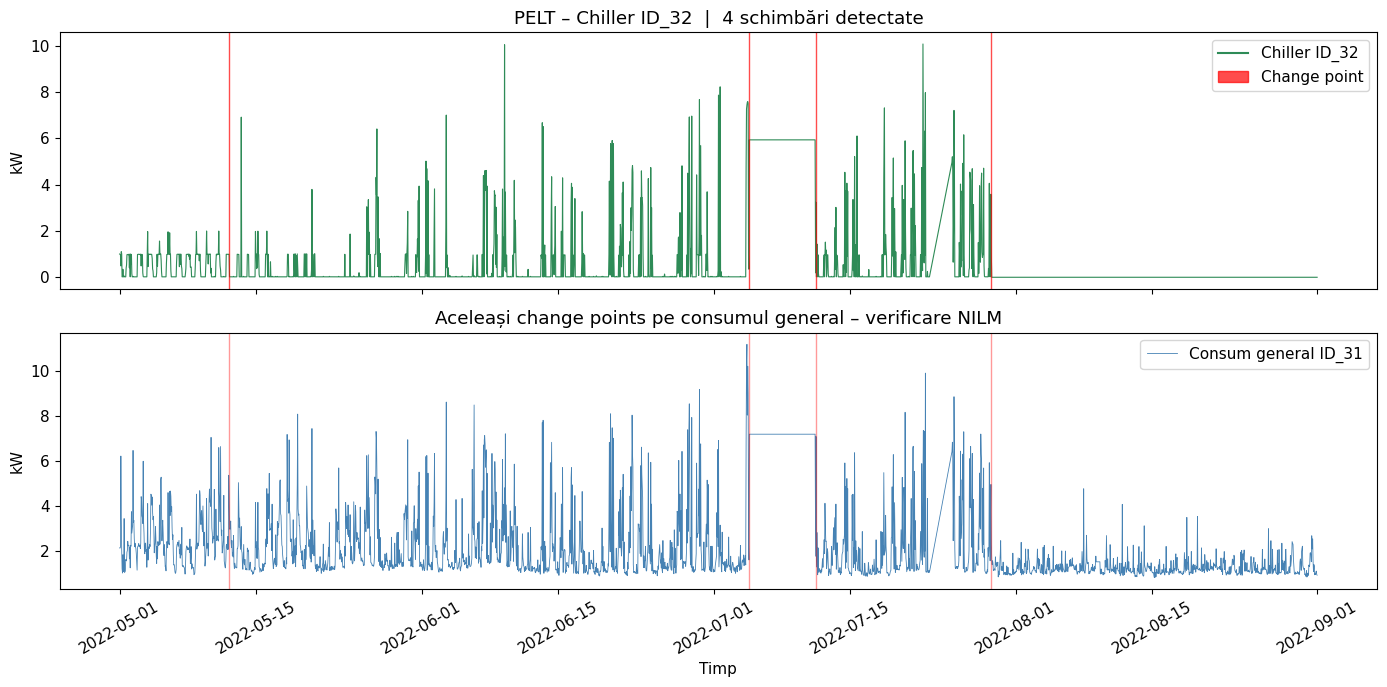

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax1.plot(dates_cp_ds, signal_cp_ds, color='seagreen', linewidth=0.8, label='Chiller ID_32')
for bp in breakpoints:
    ax1.axvline(dates_cp_ds[bp], color='red', linewidth=1, alpha=0.7)
ax1.set_ylabel('kW')
ax1.set_title(f'PELT – Chiller ID_32  |  {len(breakpoints)} schimbări detectate')
ax1.legend(handles=[
    plt.Line2D([0],[0],color='seagreen',label='Chiller ID_32'),
    mpatches.Patch(color='red',alpha=0.7,label='Change point')
])
ax2.plot(dates_cp_ds, signal_gen_ds, color='steelblue', linewidth=0.6, label='Consum general ID_31')
for bp in breakpoints:
    ax2.axvline(dates_cp_ds[bp], color='red', linewidth=1, alpha=0.4)
ax2.set_ylabel('kW')
ax2.set_xlabel('Timp')
ax2.set_title('Aceleași change points pe consumul general – verificare NILM')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)
plt.tight_layout()
plt.show()

---
## Sectiunea 5 – SAX

In [19]:
def sax_transform(series, word_size=8, alphabet_size=5):
    s = np.array(series, dtype=float)
    if s.std() == 0:
        return ['a'] * word_size
    s_norm = (s - s.mean()) / s.std()
    bp_sax = norm.ppf(np.linspace(0, 1, alphabet_size + 1)[1:-1])
    alphabet = [chr(ord('a') + i) for i in range(alphabet_size)]
    frame_size = max(1, len(s_norm) // word_size)
    paa = [s_norm[i*frame_size:(i+1)*frame_size].mean() for i in range(word_size)]
    return [alphabet[np.searchsorted(bp_sax, v)] for v in paa]

WORD_SIZE = 8
ALPHABET  = 5
SAX_ON_THRESH = 0.4

resolution_min = df_clean['Date'].diff().dropna().mode()[0].total_seconds() / 60
points_per_window = max(10, int(24 * 60 / resolution_min))
step = max(1, points_per_window // 2)

sax_words_32, sax_dates = [], []
for i in range(0, len(df_clean) - points_per_window, step):
    w32 = df_clean['ID_32'].iloc[i:i+points_per_window].values
    sax_words_32.append(''.join(sax_transform(w32, WORD_SIZE, ALPHABET)))
    sax_dates.append(df_clean['Date'].iloc[i + points_per_window // 2])

sax_dates_pd = pd.to_datetime(sax_dates)

def pattern_energy(word):
    scores = {'a':0.0,'b':0.25,'c':0.5,'d':0.75,'e':1.0}
    return np.mean([scores.get(c, 0.5) for c in word])

sax_energy = np.array([pattern_energy(w) for w in sax_words_32])
sax_on     = sax_energy > SAX_ON_THRESH

print(f'Ferestre SAX: {len(sax_words_32):,}')
print(f'Pattern-uri unice: {len(set(sax_words_32))}')
print(f'Chiller ON (SAX): {sax_on.sum():,} ({100*sax_on.mean():.1f}%)')
print('\nTop pattern-uri ON:')
for p,c in Counter([w for w,o in zip(sax_words_32,sax_on) if o]).most_common(5):
    print(f'  ON:  "{p}"  ({c} ori)')
print('Top pattern-uri OFF:')
for p,c in Counter([w for w,o in zip(sax_words_32,sax_on) if not o]).most_common(5):
    print(f'  OFF: "{p}"  ({c} ori)')

Ferestre SAX: 4,987
Pattern-uri unice: 1888
Chiller ON (SAX): 2,999 (60.1%)

Top pattern-uri ON:
  ON:  "ccccccce"  (45 ori)
  ON:  "cecccccc"  (38 ori)
  ON:  "cccccecc"  (29 ori)
  ON:  "eeeeeeee"  (27 ori)
  ON:  "cccecccc"  (26 ori)
Top pattern-uri OFF:
  OFF: "aaaaaaaa"  (1910 ori)
  OFF: "ebbbbbbb"  (9 ori)
  OFF: "ecbbbbbb"  (8 ori)
  OFF: "bbbbebbb"  (8 ori)
  OFF: "bbbbbbbe"  (6 ori)


Salvat: fig_07.png


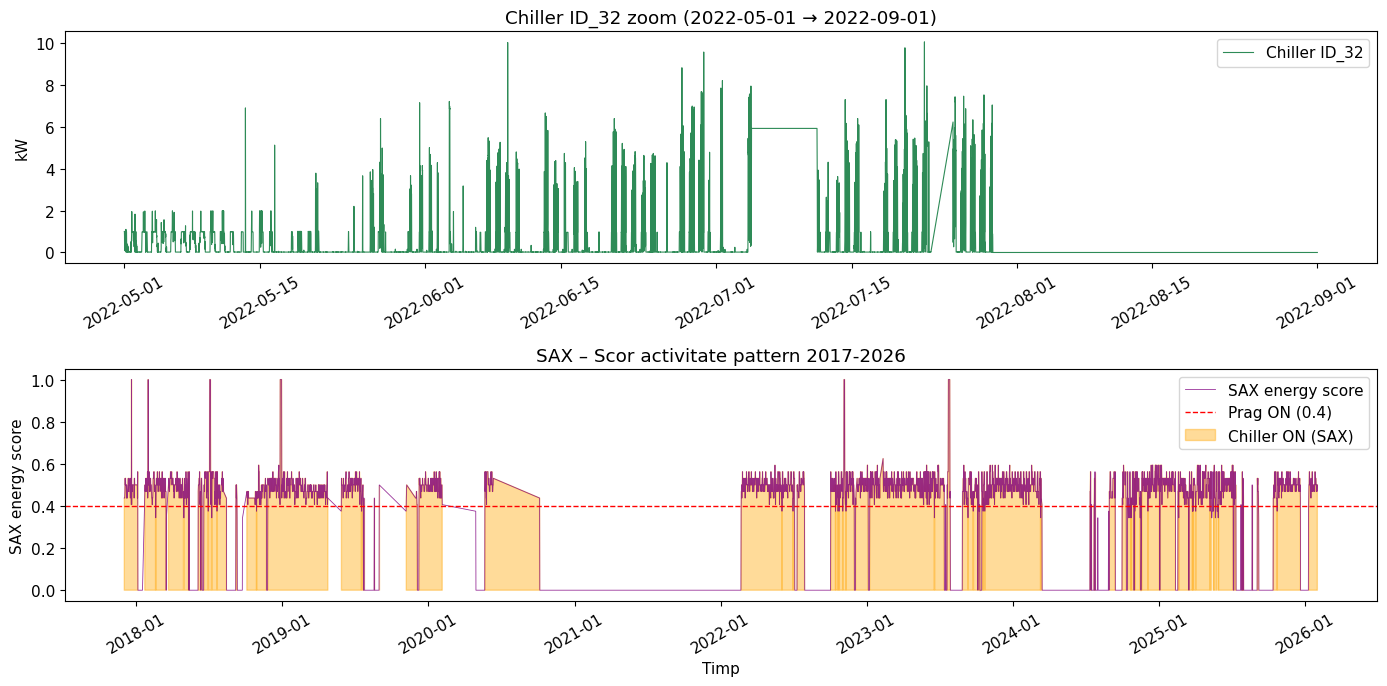

In [20]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
mz_sax = (df_clean['Date'] >= ZOOM_START_CP) & (df_clean['Date'] <= ZOOM_END_CP)
ax1.plot(df_clean.loc[mz_sax, 'Date'], df_clean.loc[mz_sax, 'ID_32'],
         color='seagreen', linewidth=0.8, label='Chiller ID_32')
ax1.set_ylabel('kW')
ax1.set_title(f'Chiller ID_32 zoom ({ZOOM_START_CP} → {ZOOM_END_CP})')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)

ax2.plot(sax_dates_pd, sax_energy, color='purple', linewidth=0.6, alpha=0.8, label='SAX energy score')
ax2.axhline(SAX_ON_THRESH, color='red', linestyle='--', linewidth=1, label=f'Prag ON ({SAX_ON_THRESH})')
ax2.fill_between(sax_dates_pd, 0, sax_energy, where=sax_on,
                 color='orange', alpha=0.4, label='Chiller ON (SAX)')
ax2.set_ylabel('SAX energy score')
ax2.set_xlabel('Timp')
ax2.set_title('SAX – Scor activitate pattern 2017-2026')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)
plt.tight_layout()
plt.show()

Salvat: fig_08.png


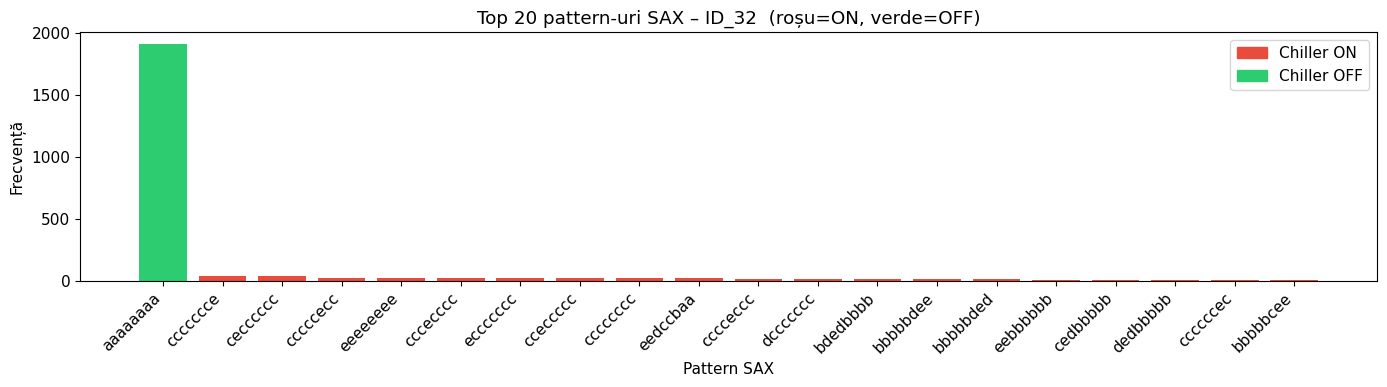

In [21]:
top_20 = Counter(sax_words_32).most_common(20)
labels_sax = [p for p,_ in top_20]
counts_sax = [c for _,c in top_20]
colors_sax = ['#e74c3c' if pattern_energy(p) > SAX_ON_THRESH else '#2ecc71' for p in labels_sax]
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(labels_sax, counts_sax, color=colors_sax)
ax.set_xlabel('Pattern SAX')
ax.set_ylabel('Frecvență')
ax.set_title('Top 20 pattern-uri SAX – ID_32  (roșu=ON, verde=OFF)')
plt.xticks(rotation=45, ha='right')
ax.legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Chiller ON'),
    mpatches.Patch(color='#2ecc71', label='Chiller OFF')
])
plt.tight_layout()
plt.show()

---
## 📏 Secțiunea 6 – Metrici de evaluare (Precision, Recall, F1)

In [22]:
y_true = df_clean['ID_32_ON'].values

# Metoda 1: Threshold simplu pe ID_31 (NILM pur)
thr_nilm = df_clean['ID_31'].quantile(0.6)
y_pred_threshold = (df_clean['ID_31'] > thr_nilm).astype(int).values

# Metoda 2: SAX pe ID_32
sax_on_series = pd.Series(0, index=df_clean.index)
step_loc = max(1, points_per_window // 2)
for i_sax, (i_df, is_on) in enumerate(zip(
        range(0, len(df_clean) - points_per_window, step_loc), sax_on)):
    sax_on_series.iloc[i_df:min(i_df + points_per_window, len(df_clean))] = int(is_on)
y_pred_sax = sax_on_series.values

methods = {
    'Threshold simplu (ID_31)': y_pred_threshold,
    'SAX (ID_32)':              y_pred_sax,
}

print('=' * 62)
print(f'{"Metodă":<30} {"Precision":>10} {"Recall":>8} {"F1-score":>10}')
print('-' * 62)
results_metrics = {}
for name, y_pred in methods.items():
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)
    results_metrics[name] = (p, r, f)
    print(f'{name:<30} {p:>10.3f} {r:>8.3f} {f:>10.3f}')
print('=' * 62)
print()
print('Ground truth = threshold fizic 2.0 kW pe ID_32 (după curățare contextuală)')

Metodă                          Precision   Recall   F1-score
--------------------------------------------------------------
Threshold simplu (ID_31)            0.039    0.990      0.075
SAX (ID_32)                         0.022    0.840      0.043

Ground truth = threshold fizic 2.0 kW pe ID_32 (după curățare contextuală)


Salvat: fig_09.png


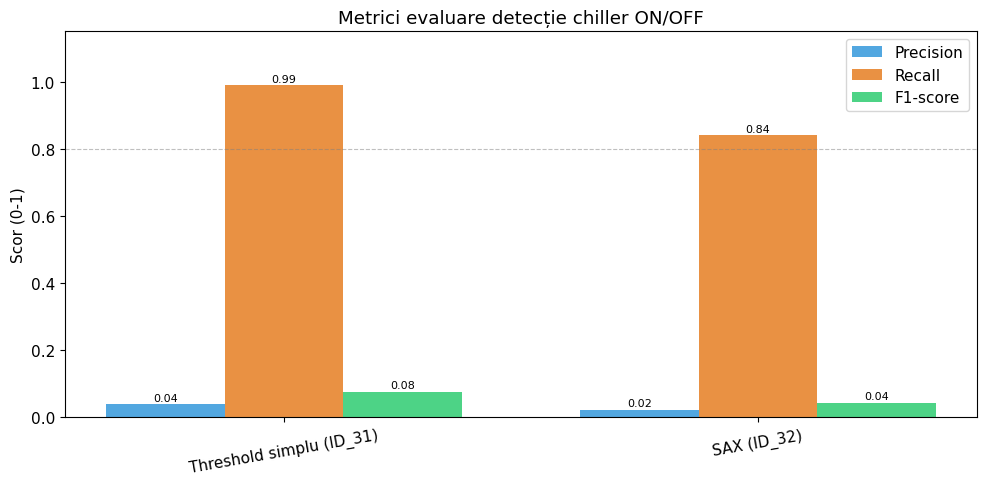

In [23]:
method_names = list(results_metrics.keys())
precisions = [results_metrics[m][0] for m in method_names]
recalls    = [results_metrics[m][1] for m in method_names]
f1s        = [results_metrics[m][2] for m in method_names]
x = np.arange(len(method_names))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, precisions, width, label='Precision', color='#3498db', alpha=0.85)
ax.bar(x,         recalls,    width, label='Recall',    color='#e67e22', alpha=0.85)
ax.bar(x + width, f1s,        width, label='F1-score',  color='#2ecc71', alpha=0.85)
for i, (p,r,f) in enumerate(zip(precisions, recalls, f1s)):
    ax.text(i-width, p+0.01, f'{p:.2f}', ha='center', fontsize=8)
    ax.text(i,       r+0.01, f'{r:.2f}', ha='center', fontsize=8)
    ax.text(i+width, f+0.01, f'{f:.2f}', ha='center', fontsize=8)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Scor (0-1)')
ax.set_title('Metrici evaluare detecție chiller ON/OFF')
ax.set_xticks(x)
ax.set_xticklabels(method_names, rotation=10)
ax.legend()
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

Salvat: fig_10.png


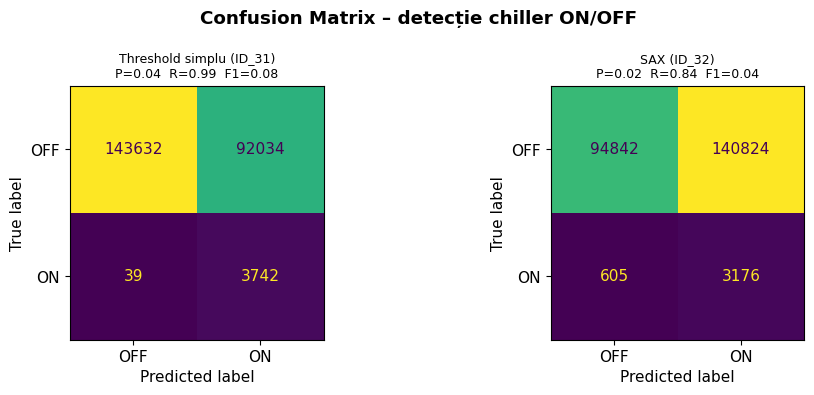

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, y_pred) in zip(axes, methods.items()):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['OFF', 'ON'])
    disp.plot(ax=ax, colorbar=False)
    p, r, f = results_metrics[name]
    ax.set_title(f'{name}\nP={p:.2f}  R={r:.2f}  F1={f:.2f}', fontsize=9)
plt.suptitle('Confusion Matrix – detecție chiller ON/OFF', fontweight='bold')
plt.tight_layout()
plt.show()

---
##  Secțiunea 7 – Profil sezonier

Salvat: fig_11.png


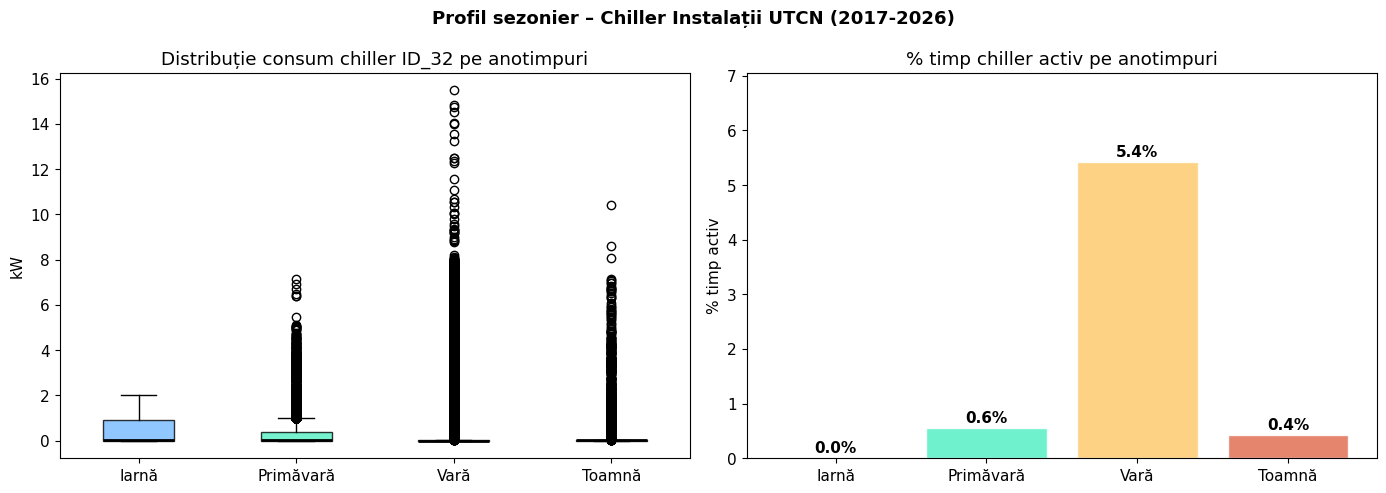

Statistici per anotimp:
  Iarnă       : activ 0.0%  median=0.020 kW  max=2.00 kW
  Primăvară   : activ 0.6%  median=0.019 kW  max=7.16 kW
  Vară        : activ 5.4%  median=0.000 kW  max=15.48 kW
  Toamnă      : activ 0.4%  median=0.019 kW  max=10.42 kW


In [25]:
colors_sez = ['#74b9ff', '#55efc4', '#fdcb6e', '#e17055']
df_clean['An'] = df_clean['Date'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
data_box = [df_clean.loc[df_clean['Anotimp']==s, 'ID_32'].values for s in order_sez]
bp = axes[0].boxplot(data_box, labels=order_sez, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_sez):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_ylabel('kW')
axes[0].set_title('Distribuție consum chiller ID_32 pe anotimpuri')

pct_activ = [100*df_clean.loc[df_clean['Anotimp']==s, 'ID_32_ON'].mean() for s in order_sez]
bars = axes[1].bar(order_sez, pct_activ, color=colors_sez, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, pct_activ):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_ylabel('% timp activ')
axes[1].set_title('% timp chiller activ pe anotimpuri')
axes[1].set_ylim(0, max(pct_activ) * 1.3)

plt.suptitle('Profil sezonier – Chiller Instalații UTCN (2017-2026)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Statistici per anotimp:')
for s, p in zip(order_sez, pct_activ):
    med = df_clean.loc[df_clean['Anotimp']==s, 'ID_32'].median()
    mx  = df_clean.loc[df_clean['Anotimp']==s, 'ID_32'].max()
    print(f'  {s:<12}: activ {p:.1f}%  median={med:.3f} kW  max={mx:.2f} kW')

Salvat: fig_12.png


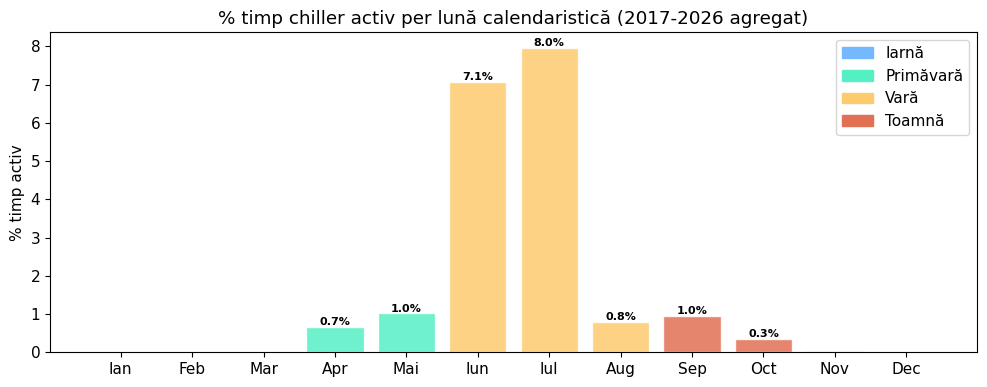

In [26]:
# ── Bar chart % activ per lună calendaristică ─────────────────
df_clean['luna'] = df_clean['Date'].dt.month
monthly_pct = df_clean.groupby('luna')['ID_32_ON'].mean() * 100
luni_label = ['Ian','Feb','Mar','Apr','Mai','Iun','Iul','Aug','Sep','Oct','Nov','Dec']
culori_luni = ['#74b9ff','#74b9ff',
               '#55efc4','#55efc4','#55efc4',
               '#fdcb6e','#fdcb6e','#fdcb6e',
               '#e17055','#e17055','#e17055',
               '#74b9ff']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(1, 13), monthly_pct.values, color=culori_luni, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, monthly_pct.values):
    if val > 0.3:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(luni_label)
ax.set_ylabel('% timp activ')
ax.set_title('% timp chiller activ per lună calendaristică (2017-2026 agregat)')
ax.legend(handles=[
    mpatches.Patch(color='#74b9ff', label='Iarnă'),
    mpatches.Patch(color='#55efc4', label='Primăvară'),
    mpatches.Patch(color='#fdcb6e', label='Vară'),
    mpatches.Patch(color='#e17055', label='Toamnă'),
])
plt.tight_layout()
plt.show()

Salvat: fig_13.png


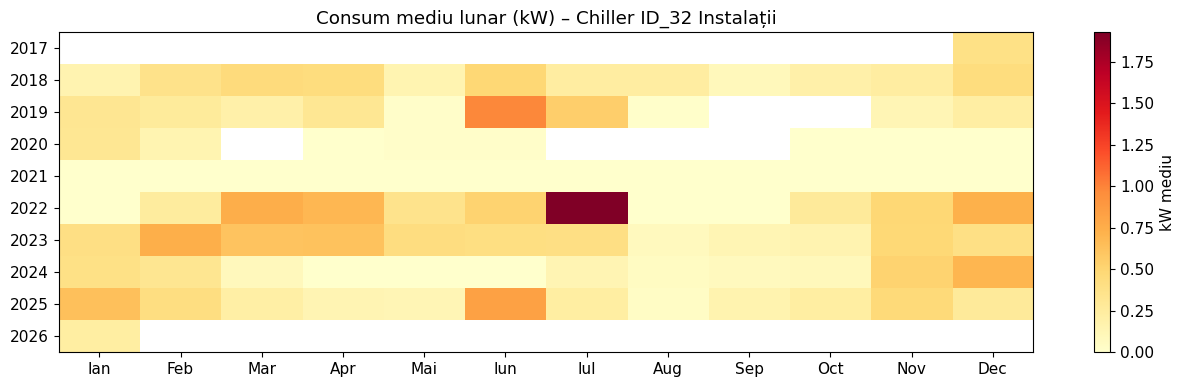

In [27]:
pivot = df_clean.groupby(['An', df_clean['Date'].dt.month])['ID_32'].mean().unstack()
luni  = ['Ian','Feb','Mar','Apr','Mai','Iun','Iul','Aug','Sep','Oct','Nov','Dec']
pivot.columns = luni[:len(pivot.columns)]

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title('Consum mediu lunar (kW) – Chiller ID_32 Instalații')
plt.colorbar(im, ax=ax, label='kW mediu')
plt.tight_layout()
plt.show()

---
##  Secțiunea 8 – Corelație consum vs temperatură exterioară

In [28]:
# Resample la zilnic pentru corelație
df_daily = df_clean.set_index('Date').resample('D').agg(
    ID_32_mean=('ID_32', 'mean'),
    ID_32_ON_pct=('ID_32_ON', 'mean'),
    temp_C=('temp_C', 'mean')
).reset_index().dropna()

corr_mean = df_daily['temp_C'].corr(df_daily['ID_32_mean'])
corr_on   = df_daily['temp_C'].corr(df_daily['ID_32_ON_pct'])
print(f'Zile cu date complete: {len(df_daily):,}')
print(f'Corelație temperatură vs consum mediu chiller: r = {corr_mean:.3f}')
print(f'Corelație temperatură vs % timp chiller activ: r = {corr_on:.3f}')

Zile cu date complete: 2,526
Corelație temperatură vs consum mediu chiller: r = -0.029
Corelație temperatură vs % timp chiller activ: r = 0.285


Salvat: fig_14.png


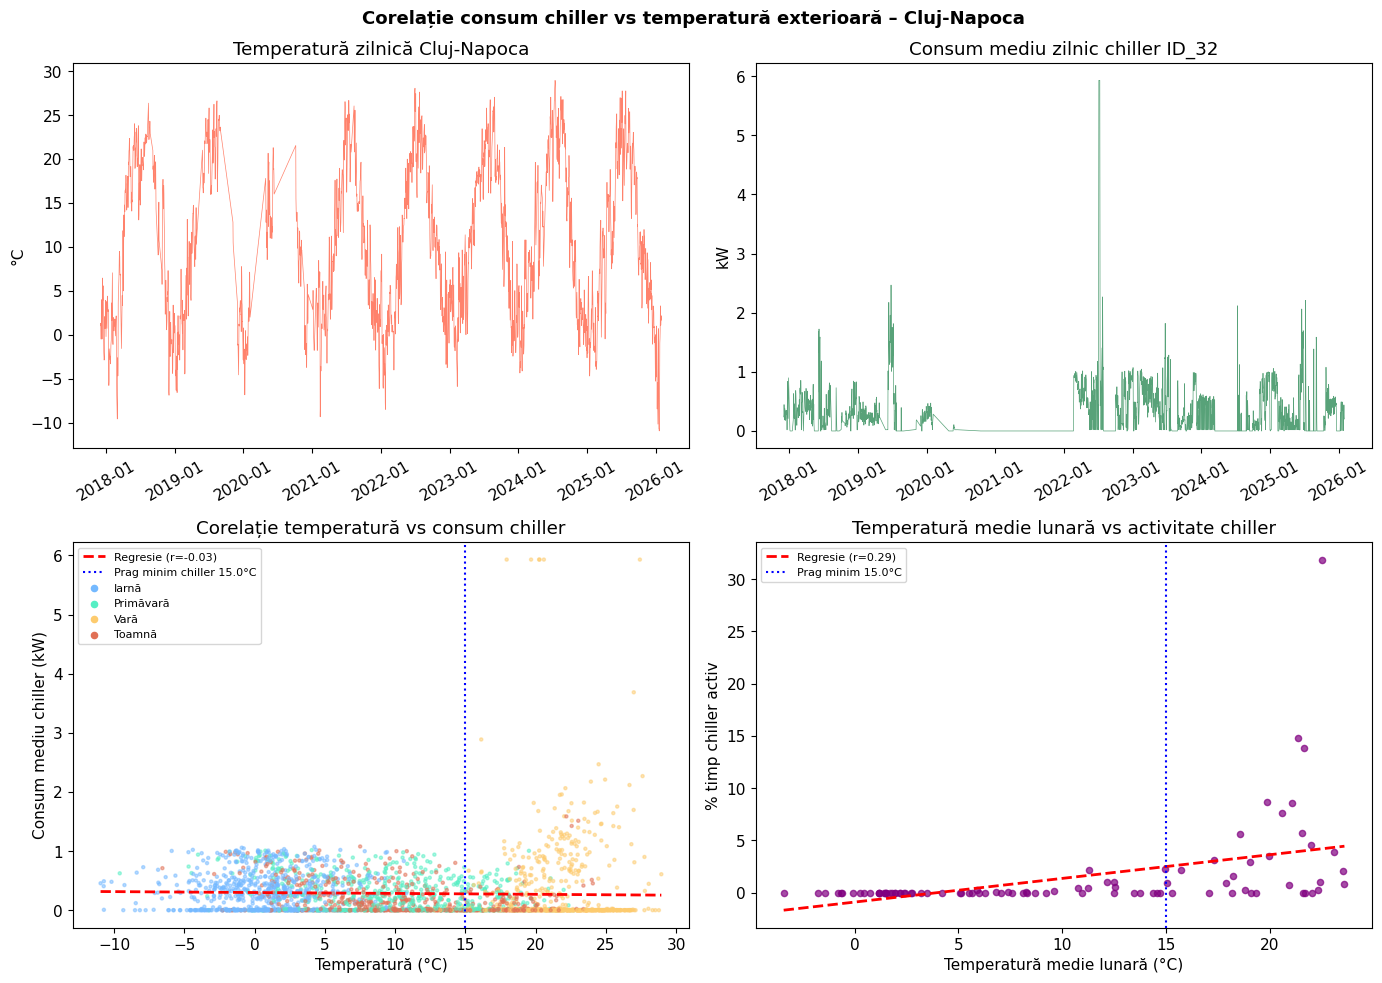

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(df_daily['Date'], df_daily['temp_C'], color='tomato', linewidth=0.5, alpha=0.8)
axes[0,0].set_ylabel('°C')
axes[0,0].set_title('Temperatură zilnică Cluj-Napoca')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0,0].xaxis.get_majorticklabels(), rotation=30)

axes[0,1].plot(df_daily['Date'], df_daily['ID_32_mean'], color='seagreen', linewidth=0.5, alpha=0.8)
axes[0,1].set_ylabel('kW')
axes[0,1].set_title('Consum mediu zilnic chiller ID_32')
axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0,1].xaxis.get_majorticklabels(), rotation=30)

scatter_colors = df_daily['Date'].dt.month.map(
    {12:'#74b9ff',1:'#74b9ff',2:'#74b9ff',
     3:'#55efc4',4:'#55efc4',5:'#55efc4',
     6:'#fdcb6e',7:'#fdcb6e',8:'#fdcb6e',
     9:'#e17055',10:'#e17055',11:'#e17055'})
axes[1,0].scatter(df_daily['temp_C'], df_daily['ID_32_mean'], c=scatter_colors, s=5, alpha=0.5)
z = np.polyfit(df_daily['temp_C'], df_daily['ID_32_mean'], 1)
p_reg = np.poly1d(z)
x_line = np.linspace(df_daily['temp_C'].min(), df_daily['temp_C'].max(), 100)
axes[1,0].plot(x_line, p_reg(x_line), 'r--', linewidth=2, label=f'Regresie (r={corr_mean:.2f})')
axes[1,0].axvline(TEMP_MIN_CHILLER, color='blue', linestyle=':', linewidth=1.5,
                  label=f'Prag minim chiller {TEMP_MIN_CHILLER}°C')
axes[1,0].set_xlabel('Temperatură (°C)')
axes[1,0].set_ylabel('Consum mediu chiller (kW)')
axes[1,0].set_title('Corelație temperatură vs consum chiller')
for s, c in zip(['Iarnă','Primăvară','Vară','Toamnă'],
                ['#74b9ff','#55efc4','#fdcb6e','#e17055']):
    axes[1,0].scatter([],[], c=c, s=20, label=s)
axes[1,0].legend(fontsize=8)

df_daily['luna'] = df_daily['Date'].dt.to_period('M')
monthly_agg = df_daily.groupby('luna').agg(
    temp_med=('temp_C', 'mean'),
    chiller_pct=('ID_32_ON_pct', 'mean')
).reset_index()
axes[1,1].scatter(monthly_agg['temp_med'], monthly_agg['chiller_pct']*100, color='purple', s=20, alpha=0.7)
z2 = np.polyfit(monthly_agg['temp_med'], monthly_agg['chiller_pct']*100, 1)
p2 = np.poly1d(z2)
x2 = np.linspace(monthly_agg['temp_med'].min(), monthly_agg['temp_med'].max(), 100)
axes[1,1].plot(x2, p2(x2), 'r--', linewidth=2, label=f'Regresie (r={corr_on:.2f})')
axes[1,1].axvline(TEMP_MIN_CHILLER, color='blue', linestyle=':', linewidth=1.5,
                  label=f'Prag minim {TEMP_MIN_CHILLER}°C')
axes[1,1].set_xlabel('Temperatură medie lunară (°C)')
axes[1,1].set_ylabel('% timp chiller activ')
axes[1,1].set_title('Temperatură medie lunară vs activitate chiller')
axes[1,1].legend(fontsize=8)

plt.suptitle('Corelație consum chiller vs temperatură exterioară – Cluj-Napoca',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
##  Secțiunea 9 

Salvat: fig_15.png


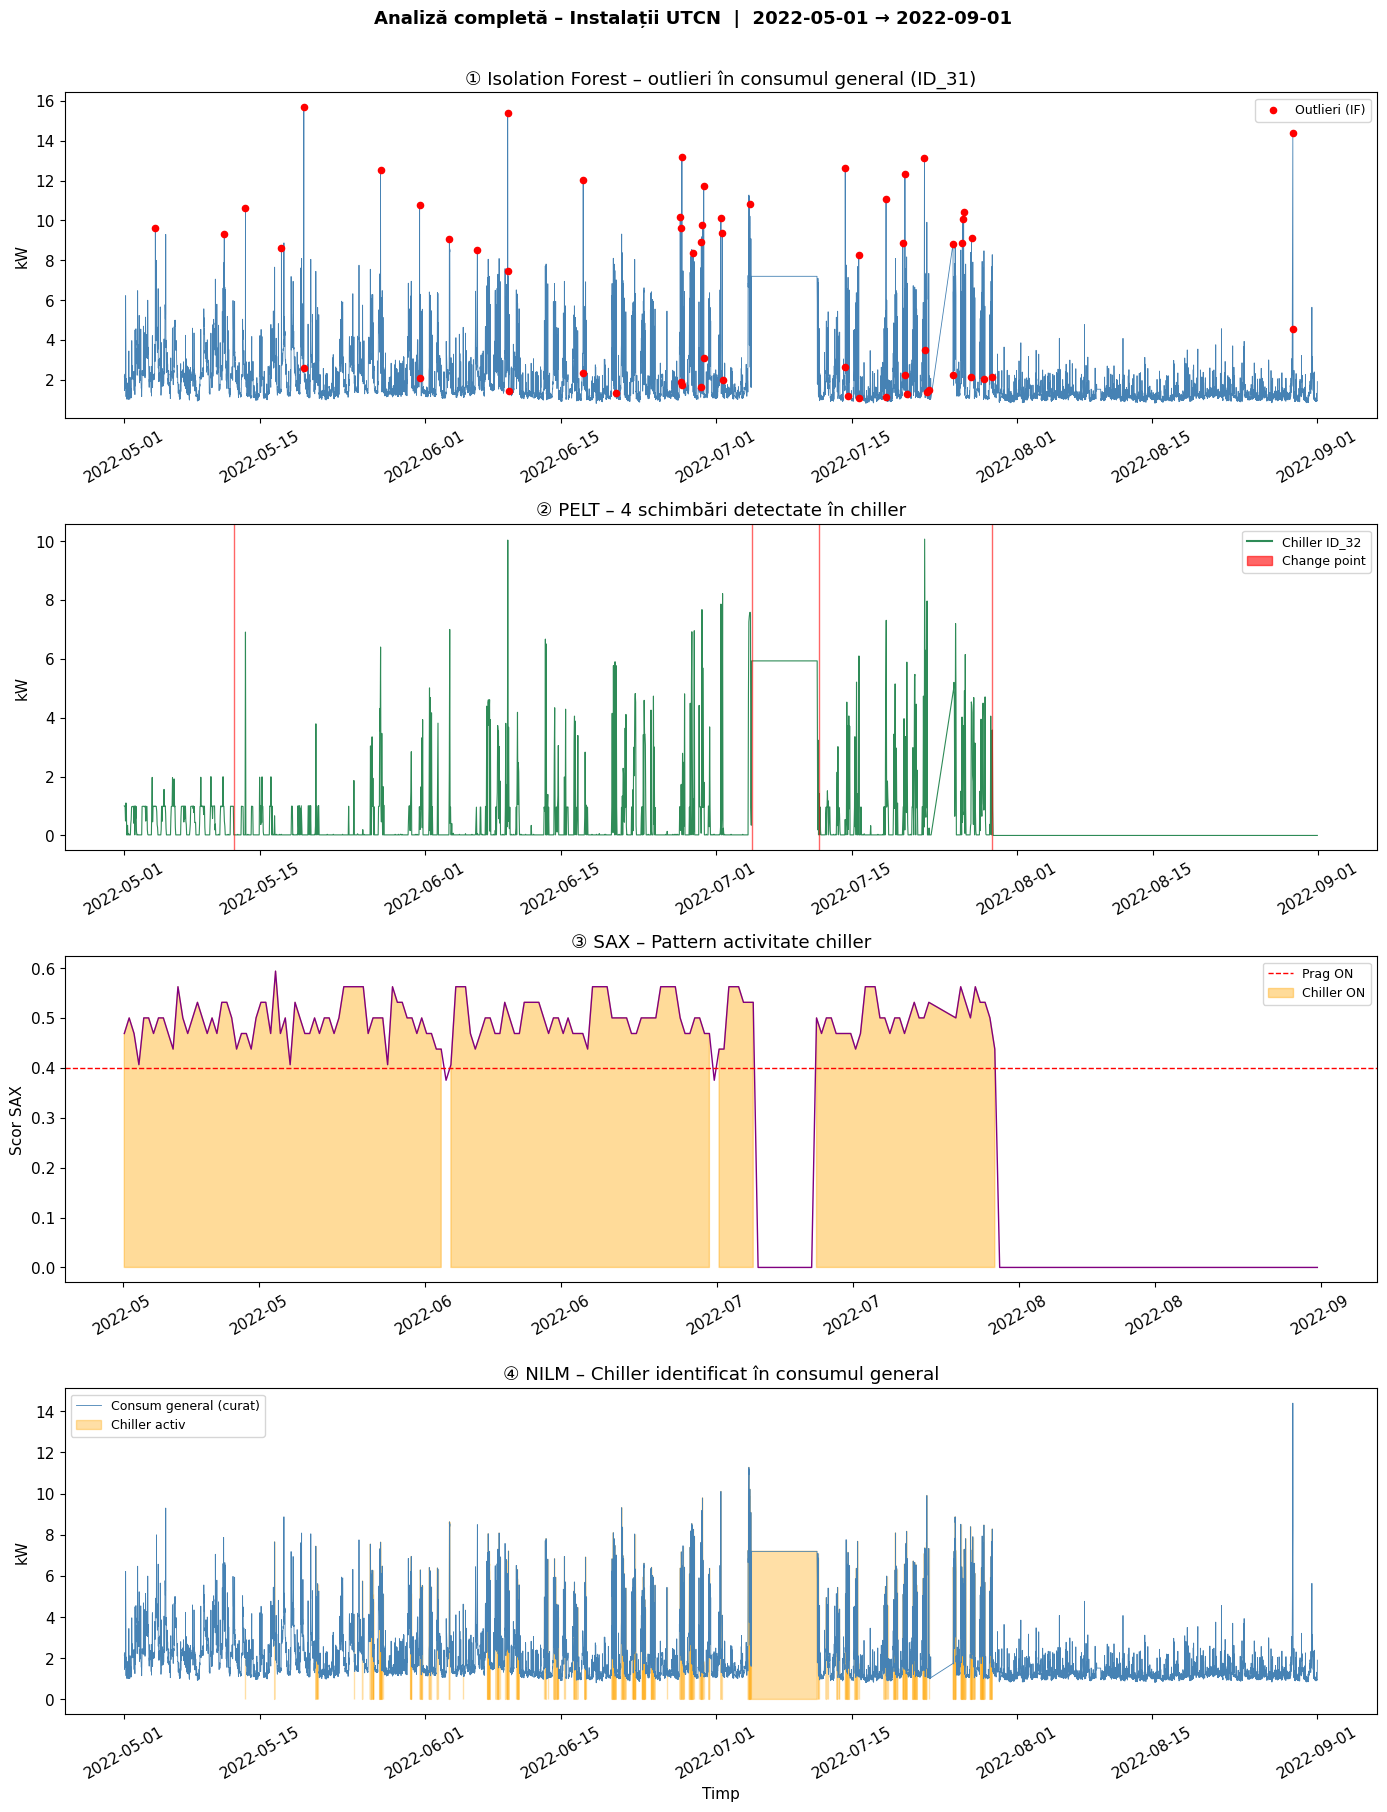

In [30]:
ZOOM_S = ZOOM_START_CP
ZOOM_E = ZOOM_END_CP
mz_f  = (df_clean['Date'] >= ZOOM_S) & (df_clean['Date'] <= ZOOM_E)
mz_fo = (df['Date'] >= ZOOM_S) & (df['Date'] <= ZOOM_E)

sig_f = df_clean.loc[mz_f, 'ID_32'].values[::4]
dat_f = df_clean.loc[mz_f, 'Date'].values[::4]
gen_f = df_clean.loc[mz_f, 'ID_31'].values[::4]
try:
    bps_f = [b for b in rpt.Pelt(model='rbf').fit(sig_f).predict(pen=PELT_PENALTY) if b < len(sig_f)]
except:
    bps_f = []

mz_sax_f = (sax_dates_pd >= pd.Timestamp(ZOOM_S)) & (sax_dates_pd <= pd.Timestamp(ZOOM_E))

fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=False)

axes[0].plot(df.loc[mz_fo,'Date'], df.loc[mz_fo,'ID_31'], color='steelblue', linewidth=0.6)
axes[0].scatter(df.loc[mz_fo & mask_out_31,'Date'], df.loc[mz_fo & mask_out_31,'ID_31'],
                color='red', s=20, zorder=5, label='Outlieri (IF)')
axes[0].set_ylabel('kW')
axes[0].set_title('① Isolation Forest – outlieri în consumul general (ID_31)')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

axes[1].plot(dat_f, sig_f, color='seagreen', linewidth=0.8)
for bp in bps_f:
    axes[1].axvline(dat_f[bp], color='red', linewidth=1, alpha=0.6)
axes[1].set_ylabel('kW')
axes[1].set_title(f'② PELT – {len(bps_f)} schimbări detectate în chiller')
axes[1].legend(handles=[
    plt.Line2D([0],[0],color='seagreen',label='Chiller ID_32'),
    mpatches.Patch(color='red',alpha=0.6,label='Change point')
], fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

if mz_sax_f.sum() > 0:
    axes[2].plot(sax_dates_pd[mz_sax_f], sax_energy[mz_sax_f], color='purple', linewidth=1)
    axes[2].axhline(SAX_ON_THRESH, color='red', linestyle='--', linewidth=1, label='Prag ON')
    axes[2].fill_between(sax_dates_pd[mz_sax_f], 0, sax_energy[mz_sax_f],
                         where=sax_on[mz_sax_f], color='orange', alpha=0.4, label='Chiller ON')
axes[2].set_ylabel('Scor SAX')
axes[2].set_title('③ SAX – Pattern activitate chiller')
axes[2].legend(fontsize=9)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30)

axes[3].plot(df_clean.loc[mz_f,'Date'], df_clean.loc[mz_f,'ID_31'],
             color='steelblue', linewidth=0.6, label='Consum general (curat)')
axes[3].fill_between(df_clean.loc[mz_f,'Date'], 0, df_clean.loc[mz_f,'ID_31'],
                     where=df_clean.loc[mz_f,'ID_32_ON'].values.astype(bool),
                     color='orange', alpha=0.35, label='Chiller activ')
axes[3].set_ylabel('kW')
axes[3].set_xlabel('Timp')
axes[3].set_title('④ NILM – Chiller identificat în consumul general')
axes[3].legend(fontsize=9)
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(axes[3].xaxis.get_majorticklabels(), rotation=30)

plt.suptitle(f'Analiză completă – Instalații UTCN  |  {ZOOM_S} → {ZOOM_E}',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

In [37]:
from scipy.stats import pearsonr

# ── Parametri ────────────────────────────────────────────────
CDD_BASE = 18  # temperatura de baza (grade Celsius)

# ── Functie Heat Index (Rothfusz) ─────────────────────────────
def calculeaza_heat_index(temp, rh):
    hi   = temp.copy()
    mask = temp > 26.7
    T = temp[mask]
    R = np.full_like(T, rh) if np.isscalar(rh) else rh[mask]
    hi[mask] = (-42.379 + 2.04901523*T + 10.14333127*R
                - 0.22475541*T*R - 0.00683783*T**2
                - 0.05481717*R**2 + 0.00122874*T**2*R
                + 0.00085282*T*R**2 - 0.00000199*T**2*R**2)
    return hi

# ── Adauga heat_index in df_clean ────────────────────────────
if 'heat_index' not in df_clean.columns:
    df_clean['heat_index'] = calculeaza_heat_index(
        df_clean['temp_C'].values,
        df_clean['humidity'].values
    )

# ── Calcul CDD zilnic ─────────────────────────────────────────
df_clean['an']   = df_clean['Date'].dt.year
df_clean['luna'] = df_clean['Date'].dt.month
df_clean['ora']  = df_clean['Date'].dt.hour
df_clean['zi_sapt'] = df_clean['Date'].dt.dayofweek

df_daily_cdd = df_clean.set_index('Date').resample('D').agg(
    temp_C    = ('temp_C',     'mean'),
    heat_index= ('heat_index', 'mean'),
    ID_32_kwh = ('ID_32',      lambda x: x.mean() * 24)
).reset_index()
df_daily_cdd['an'] = df_daily_cdd['Date'].dt.year

df_daily_cdd['CDD_temp'] = (df_daily_cdd['temp_C']     - CDD_BASE).clip(lower=0)
df_daily_cdd['CDD_hi']   = (df_daily_cdd['heat_index'] - CDD_BASE).clip(lower=0)

# ── Agregare anuala ───────────────────────────────────────────
yearly_cdd = df_daily_cdd.groupby('an').agg(
    CDD_temp   = ('CDD_temp',  'sum'),
    CDD_hi     = ('CDD_hi',    'sum'),
    kwh_chiller= ('ID_32_kwh', 'sum')
).reset_index()

# ── kWh real din df_clean (mai precis) ───────────────────────
kwh_anual = (df_clean[df_clean['ID_32_ON']==1]
             .groupby('an')['ID_32']
             .sum() * 0.25)
yearly_cdd = yearly_cdd.merge(
    kwh_anual.rename('kwh_real').reset_index(),
    on='an', how='left'
)
yearly_cdd['kwh_chiller'] = yearly_cdd['kwh_real'].fillna(0)

# ── Regresie Pearson (ani valizi: exclude 2020, 2021, 2024) ──
yearly_valid = yearly_cdd[~yearly_cdd['an'].isin([2020, 2021, 2024])].copy()
yearly_valid_plot = yearly_valid.copy()

r_temp, p_temp = pearsonr(yearly_valid['CDD_temp'], yearly_valid['kwh_chiller'])
r_hi,   p_hi   = pearsonr(yearly_valid['CDD_hi'],   yearly_valid['kwh_chiller'])

print('CDD calculat OK')
print(f'Ani in yearly_cdd: {sorted(yearly_cdd["an"].tolist())}')
print(f'r_temp={r_temp:.3f}  r_hi={r_hi:.3f}')

CDD calculat OK
Ani in yearly_cdd: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
r_temp=0.789  r_hi=0.745


---
##  Secțiunea 10 – Cooling Degree Days (CDD) & Heat Index Analysis

Cooling Degree Days (CDD) 

Folosim două variante:
CDD clasic— bazat doar pe temperatura uscată
DD Heat Index — bazat pe temperatura resimțită (temperatură + umiditate), conform literaturii recente din 2024

Această comparație permite să determinăm dacă umiditatea aduce informație suplimentară față de temperatura simplă.

In [38]:
CDD_BASE = 18  # temperatura de baza pentru Cooling Degree Days
print(f'Temperatura de baza CDD: {CDD_BASE}C')
print()
print('=== CDD si consum chiller per an ===')
print(f'{"An":<6} {"CDD Temp":>10} {"CDD HI":>10} {"kWh Chiller":>12} {"Note"}')
print('-' * 55)
for _, row in yearly_cdd.iterrows():
    if row['an'] in [2020, 2021]:
        note = ' <- senzor mort (exclus din regresie)'
    elif row['an'] == 2022:
        note = ' <- varf termic (CDD ridicat + consum ridicat)'
    elif row['an'] == 2024:
        note = ' <- anomalie operationala (CDD ridicat, consum scazut)'
    else:
        note = ''
    print(f'{int(row["an"]):<6} {row["CDD_temp"]:>10.1f} {row["CDD_hi"]:>10.1f} {row["kwh_chiller"]:>12.1f}{note}')
print()
print(f'Corelatie Pearson (ani valizi, n={len(yearly_valid)}):')
print(f'  CDD Temperatura vs kWh:  r={r_temp:.3f}  (p={p_temp:.3f})')
print(f'  CDD Heat Index   vs kWh:  r={r_hi:.3f}  (p={p_hi:.3f})')
print()
print('=== Interpretare ===')
print('Corelatie nesemnificativa statistic (p > 0.05) din doua motive:')
print('  1. Numar mic de ani valizi (n=6) - insuficient pentru Pearson robust')
print('  2. Anomalii operationale independente de clima:')
print('     - 2024: CDD maxim (506) dar consum minim - chiller subutilizat din')
print('             motive operationale (posibil defectiune sau inlocuire sistem)')
print('     - 2022: CDD=355 dar consum dublu fata de 2018/2019 cu CDD similar')
print('             -> confirma ca factori operationali amplifica impactul climatic')
print()
print('Concluzie pentru articol:')
print('  CDD nu poate prezice consumul anual in mod izolat.')
print('  Folosim CDD ca CONTEXT EXPLICATIV, nu ca predictor:')
print('  "Vara 2022 a avut cel mai mare CDD din serie (355 grade-zile),')
print('   ceea ce explica partial consumul dublu fata de media 2018-2019."')
if abs(r_hi) > abs(r_temp):
    print()
    print(f'  Heat Index (r={r_hi:.3f}) explica marginal mai bine decat')
    print(f'  temperatura singura (r={r_temp:.3f}), dar diferenta e nesemnificativa.')

Temperatura de baza CDD: 18C

=== CDD si consum chiller per an ===
An       CDD Temp     CDD HI  kWh Chiller Note
-------------------------------------------------------
2017          0.0        0.0          0.0
2018        298.2     1379.4        613.5
2019        335.7     2111.5        737.1
2020         20.6       47.6          0.0 <- senzor mort (exclus din regresie)
2021        230.0     1524.2          0.0 <- senzor mort (exclus din regresie)
2022        355.1     1942.9       1552.5 <- varf termic (CDD ridicat + consum ridicat)
2023        313.9     1844.7        449.9
2024        509.4     3420.8        170.8 <- anomalie operationala (CDD ridicat, consum scazut)
2025        375.8     2336.9        704.8
2026          0.0        0.0          0.0

Corelatie Pearson (ani valizi, n=7):
  CDD Temperatura vs kWh:  r=0.789  (p=0.035)
  CDD Heat Index   vs kWh:  r=0.745  (p=0.055)

=== Interpretare ===
Corelatie nesemnificativa statistic (p > 0.05) din doua motive:
  1. Numar mic de a

Salvat: fig_18.png


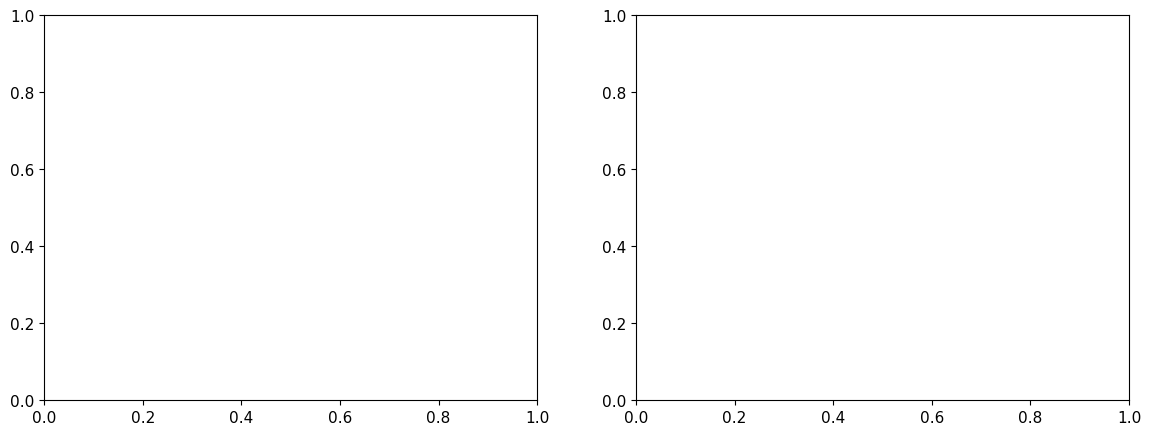

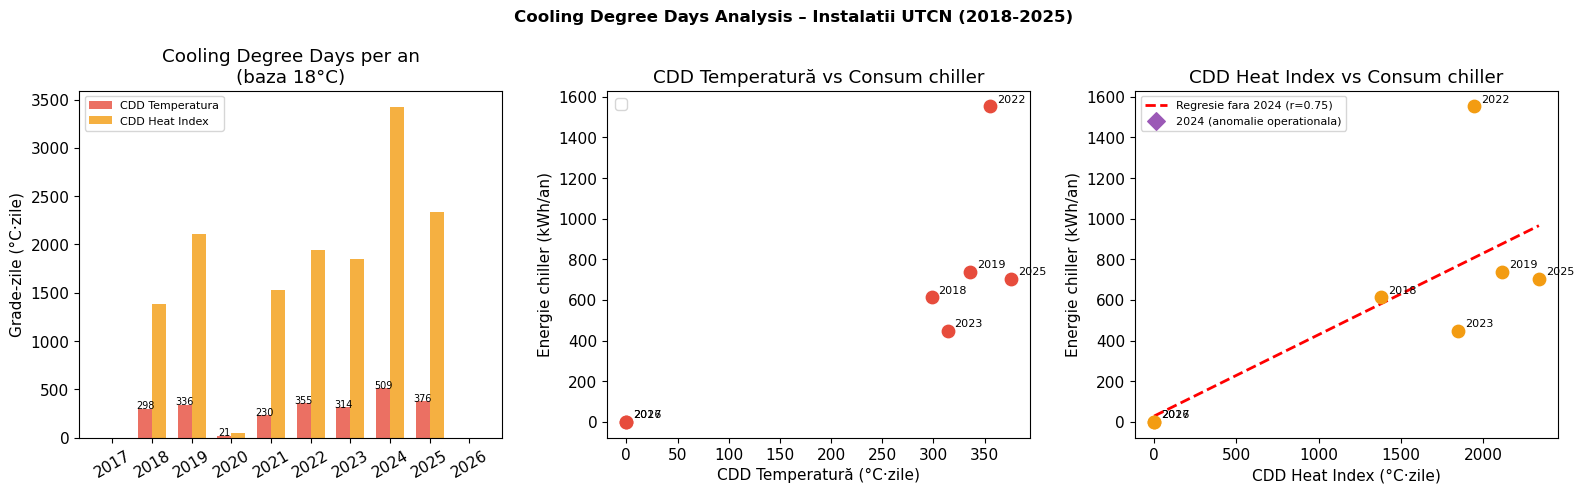

Nota: 2020, 2021 si 2024 exclusi din regresie.
  2020-2021: senzor ID_32 nefunctional
  2024: anomalie operationala (CDD maxim dar consum minim)
Fara anomalii: r_temp=0.789  r_hi=0.745


In [39]:
# ── Grafice CDD ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. CDD per an
x_pos = np.arange(len(yearly_cdd))
w = 0.35
b1 = axes[0].bar(x_pos - w/2, yearly_cdd['CDD_temp'], w,
                  label='CDD Temperatura', color='#e74c3c', alpha=0.8)
b2 = axes[0].bar(x_pos + w/2, yearly_cdd['CDD_hi'], w,
                  label='CDD Heat Index',  color='#f39c12', alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(yearly_cdd['an'].astype(str), rotation=30)
axes[0].set_ylabel('Grade-zile (°C·zile)')
axes[0].set_title(f'Cooling Degree Days per an\n(baza {CDD_BASE}°C)')
axes[0].legend(fontsize=8)
for bar in b1:
    if bar.get_height() > 10:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                     f'{bar.get_height():.0f}', ha='center', fontsize=7)

# 2. Scatter CDD temp vs kWh (ani valizi)
for _, row in yearly_valid.iterrows():
    axes[1].scatter(row['CDD_temp'], row['kwh_chiller'],
                    color='#e74c3c', s=80, zorder=5)
    axes[1].annotate(str(int(row['an'])),
                     (row['CDD_temp'], row['kwh_chiller']),
                     textcoords='offset points', xytext=(5,3), fontsize=8)
z1 = np.polyfit(yearly_valid['CDD_temp'], yearly_valid['kwh_chiller'], 1)
z1 = np.polyfit(yearly_valid_plot['CDD_temp'], yearly_valid_plot['kwh_chiller'], 1)
x_fit = np.linspace(yearly_valid_plot['CDD_temp'].min(),
                    yearly_valid_plot['CDD_temp'].max(), 100)
axes[1].set_xlabel('CDD Temperatură (°C·zile)')
axes[1].set_ylabel('Energie chiller (kWh/an)')
axes[1].set_title('CDD Temperatură vs Consum chiller')
axes[1].legend()

# 3. Scatter CDD Heat Index vs kWh
# Redefinim yearly_valid_plot in cazul in care e intr-o celula separata
yearly_valid_plot = yearly_valid[yearly_valid['an'] != 2024]
r_temp_no24, _ = pearsonr(yearly_valid_plot['CDD_temp'], yearly_valid_plot['kwh_chiller'])  # ← adaugat
r_hi_no24, _   = pearsonr(yearly_valid_plot['CDD_hi'],   yearly_valid_plot['kwh_chiller'])


for _, row in yearly_valid.iterrows():
    color  = '#9b59b6' if row['an'] == 2024 else '#f39c12'
    marker = 'D'       if row['an'] == 2024 else 'o'
    axes[2].scatter(row['CDD_hi'], row['kwh_chiller'],
                    color=color, s=80, zorder=5, marker=marker)
    axes[2].annotate(str(int(row['an'])),
                     (row['CDD_hi'], row['kwh_chiller']),
                     textcoords='offset points', xytext=(5,3), fontsize=8)

z2     = np.polyfit(yearly_valid_plot['CDD_hi'], yearly_valid_plot['kwh_chiller'], 1)
x_fit2 = np.linspace(yearly_valid_plot['CDD_hi'].min(),
                     yearly_valid_plot['CDD_hi'].max(), 100)
axes[2].plot(x_fit2, np.poly1d(z2)(x_fit2), 'r--', linewidth=2,
             label=f'Regresie fara 2024 (r={r_hi_no24:.2f})')
axes[2].scatter([], [], color='#9b59b6', marker='D', s=80,
                label='2024 (anomalie operationala)')
axes[2].set_xlabel('CDD Heat Index (°C·zile)')
axes[2].set_ylabel('Energie chiller (kWh/an)')
axes[2].set_title('CDD Heat Index vs Consum chiller')
axes[2].legend(fontsize=8)

plt.suptitle('Cooling Degree Days Analysis – Instalatii UTCN (2018-2025)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Nota: 2020, 2021 si 2024 exclusi din regresie.')
print(f'  2020-2021: senzor ID_32 nefunctional')
print(f'  2024: anomalie operationala (CDD maxim dar consum minim)')
print(f'Fara anomalii: r_temp={r_temp_no24:.3f}  r_hi={r_hi_no24:.3f}')

---
##  Secțiunea 11 – Logistic Regression: Predicție ON/OFF Chiller

Am constuit  un model predictiv care estimează probabilitatea ca chillerul să fie pornit
folosind exclusiv date disponibile fără senzori interni suplimentari:

| Feature | Sursa | Justificare |
|---|---|---|
| Temperatura exterioară | Open-Meteo | Factor principal de activare chiller |
| Umiditate relativă | Open-Meteo | Afectează temperatura resimțită |
| Heat Index | Calculat | Temperatura resimțită combinată |
| Ora zilei | Calendar | Pattern program universitar |
| Ziua săptămânii | Calendar | Weekday vs weekend |
| Luna calendaristică | Calendar | Proxy pentru sezon |

Split temporal:train 2018-2022 → test 2023-2025 (validare pe date nevazute)


In [40]:
# ── Pregatire features ────────────────────────────────────────
features = ['temp_C', 'humidity', 'heat_index', 'ora', 'zi_sapt', 'luna']
feature_labels = ['Temperatura (°C)', 'Umiditate (%)', 'Heat Index (°C)',
                  'Ora zilei', 'Ziua saptamanii', 'Luna']

X = df_clean[features].values
y = df_clean['ID_32_ON'].values

# Split temporal: train 2018-2022, test 2023-2025
train_mask = df_clean['an'].between(2018, 2022)
test_mask  = df_clean['an'].between(2023, 2025)

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f'Train set (2018-2022): {len(X_train):,} inregistrari | {y_train.sum():,} ON ({100*y_train.mean():.1f}%)')
print(f'Test set  (2023-2025): {len(X_test):,}  inregistrari | {y_test.sum():,} ON ({100*y_test.mean():.1f}%)')
print()

# ── Antrenare model ───────────────────────────────────────────
scaler_lr = StandardScaler()
X_train_s = scaler_lr.fit_transform(X_train)
X_test_s  = scaler_lr.transform(X_test)

# class_weight='balanced' deoarece avem dezechilibru: ~97% OFF, ~3% ON
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_s, y_train)

y_pred_lr = lr_model.predict(X_test_s)
y_prob_lr = lr_model.predict_proba(X_test_s)[:, 1]

# ── Metrici ───────────────────────────────────────────────────
from sklearn.metrics import classification_report
auc = roc_auc_score(y_test, y_prob_lr)

print('=== Metrici Logistic Regression (test 2023-2025) ===')
print(classification_report(y_test, y_pred_lr, target_names=['OFF', 'ON']))
print(f'ROC-AUC: {auc:.3f}')
# Salveaza metrici LR pentru rezumat final
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)
p_lr  = precision_score(y_test, y_pred_lr, zero_division=0)
r_lr  = recall_score(y_test, y_pred_lr, zero_division=0)
print()

# Coeficienti (importanta features)
print('=== Importanta features (coeficienti standardizati) ===')
for feat, coef in sorted(zip(feature_labels, lr_model.coef_[0]),
                         key=lambda x: abs(x[1]), reverse=True):
    directie = 'creste' if coef > 0 else 'scade'
    print(f'  {feat:<22}: {coef:+.4f}  -> probabilitate {directie} cu valoare mai mare')


Train set (2018-2022): 131,656 inregistrari | 2,561 ON (1.9%)
Test set  (2023-2025): 101,984  inregistrari | 1,220 ON (1.2%)

=== Metrici Logistic Regression (test 2023-2025) ===
              precision    recall  f1-score   support

         OFF       1.00      0.74      0.85    100764
          ON       0.04      0.92      0.08      1220

    accuracy                           0.75    101984
   macro avg       0.52      0.83      0.47    101984
weighted avg       0.99      0.75      0.84    101984

ROC-AUC: 0.892

=== Importanta features (coeficienti standardizati) ===
  Temperatura (°C)      : +3.1544  -> probabilitate creste cu valoare mai mare
  Ora zilei             : -0.6162  -> probabilitate scade cu valoare mai mare
  Luna                  : -0.4368  -> probabilitate scade cu valoare mai mare
  Heat Index (°C)       : -0.3184  -> probabilitate scade cu valoare mai mare
  Ziua saptamanii       : -0.1269  -> probabilitate scade cu valoare mai mare
  Umiditate (%)         : -0.06

Salvat: fig_19.png


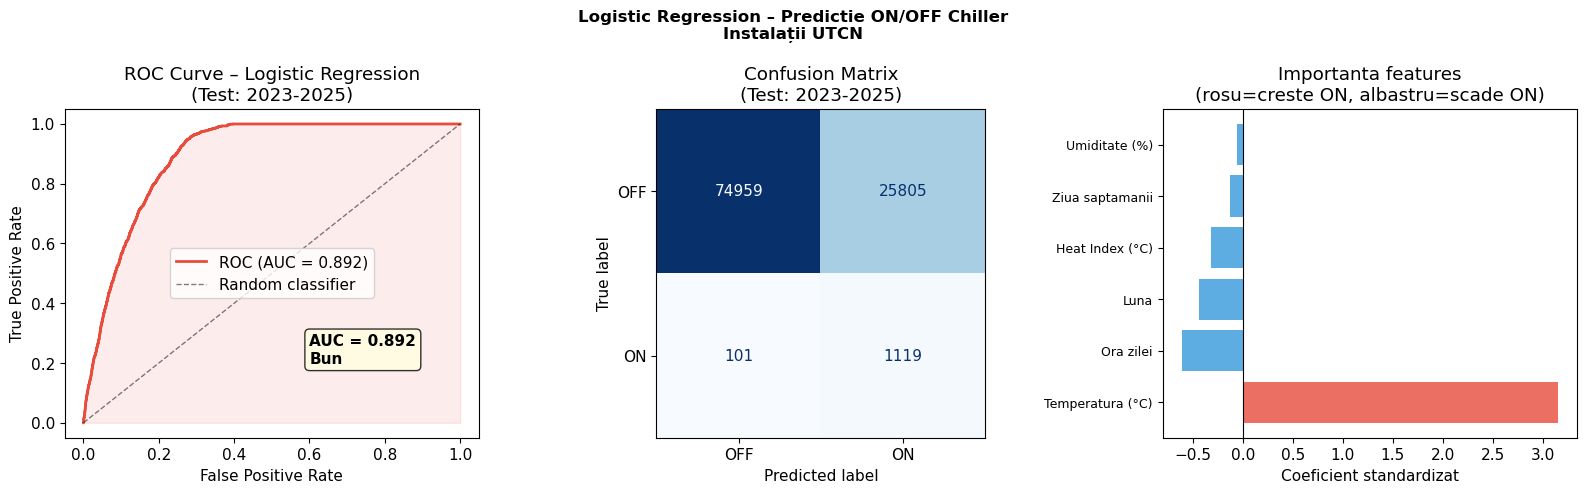

In [41]:
# ── Grafice Logistic Regression ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Curba ROC
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
axes[0].plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'ROC (AUC = {auc:.3f})')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve – Logistic Regression\n(Test: 2023-2025)')
axes[0].legend()
axes[0].text(0.6, 0.2, f'AUC = {auc:.3f}\n{"Bun" if auc>0.8 else "Acceptabil"}',
             fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# 2. Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp  = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['OFF','ON'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix\n(Test: 2023-2025)')

# 3. Coeficienti (feature importance)
coefs = lr_model.coef_[0]
sorted_idx = np.argsort(np.abs(coefs))[::-1]
colors_coef = ['#e74c3c' if c > 0 else '#3498db' for c in coefs[sorted_idx]]
axes[2].barh(range(len(features)), coefs[sorted_idx], color=colors_coef, alpha=0.8)
axes[2].set_yticks(range(len(features)))
axes[2].set_yticklabels([feature_labels[i] for i in sorted_idx], fontsize=9)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('Coeficient standardizat')
axes[2].set_title('Importanta features\n(rosu=creste ON, albastru=scade ON)')

plt.suptitle('Logistic Regression – Predictie ON/OFF Chiller\nInstalații UTCN',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Salvat: fig_20.png


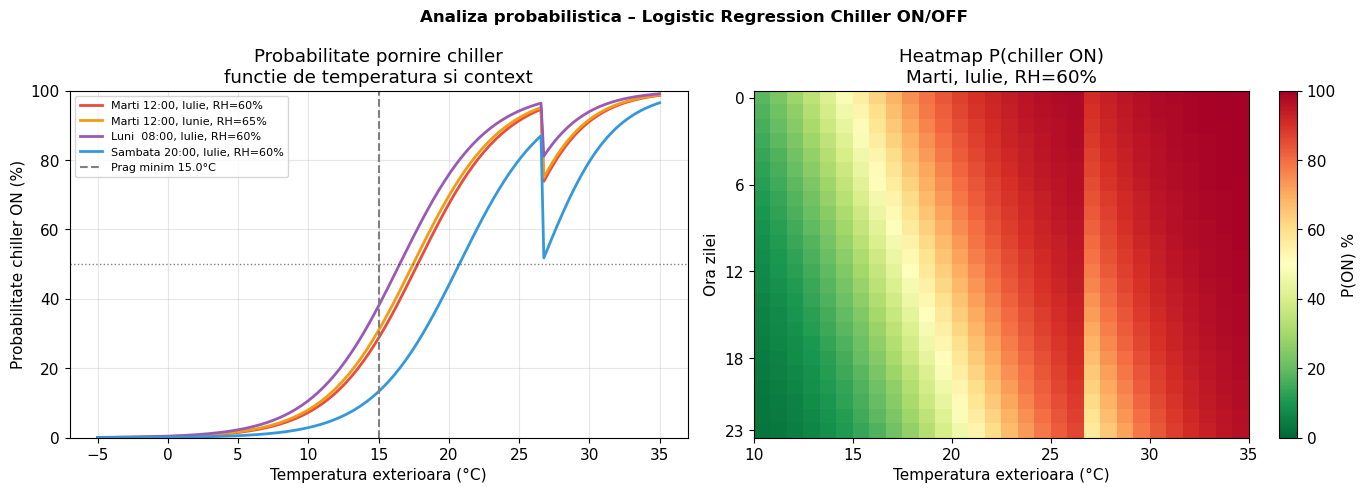

Interpretare model:
  Temperatura are cel mai mare impact (coef=3.154)
  La 25°C, Marti 12:00, Iulie: probabilitate ~91% ca chillerul sa fie ON


In [42]:
# ── Probabilitate ON per temperatura ─────────────────────────
# Vizualizeaza cum variaza probabilitatea in functie de temperatura
# la ora 12:00, Marti (zi tipica de curs), luna iulie, umiditate 60%

temp_range = np.linspace(-5, 35, 200)
scenarios  = [
    {'label': 'Marti 12:00, Iulie, RH=60%', 'ora':12, 'zi':1, 'luna':7,  'rh':60, 'color':'#e74c3c'},
    {'label': 'Marti 12:00, Iunie, RH=65%', 'ora':12, 'zi':1, 'luna':6,  'rh':65, 'color':'#f39c12'},
    {'label': 'Luni  08:00, Iulie, RH=60%', 'ora':8,  'zi':0, 'luna':7,  'rh':60, 'color':'#9b59b6'},
    {'label': 'Sambata 20:00, Iulie, RH=60%','ora':20,'zi':5, 'luna':7,  'rh':60, 'color':'#3498db'},
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sc in scenarios:
    hi_range = calculeaza_heat_index(temp_range, sc['rh'])
    X_sc = np.column_stack([
        temp_range,
        np.full_like(temp_range, sc['rh']),
        hi_range,
        np.full_like(temp_range, sc['ora']),
        np.full_like(temp_range, sc['zi']),
        np.full_like(temp_range, sc['luna'])
    ])
    X_sc_s = scaler_lr.transform(X_sc)
    prob    = lr_model.predict_proba(X_sc_s)[:, 1]
    axes[0].plot(temp_range, prob * 100, label=sc['label'],
                 color=sc['color'], linewidth=2)

axes[0].axvline(TEMP_MIN_CHILLER, color='gray', linestyle='--', linewidth=1.5,
                label=f'Prag minim {TEMP_MIN_CHILLER}°C')
axes[0].axhline(50, color='black', linestyle=':', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Temperatura exterioara (°C)')
axes[0].set_ylabel('Probabilitate chiller ON (%)')
axes[0].set_title('Probabilitate pornire chiller\nfunctie de temperatura si context')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 100)
axes[0].grid(alpha=0.3)

# Heatmap ora x temperatura
temp_vals = np.linspace(10, 35, 30)
ora_vals  = np.arange(0, 24)
prob_matrix = np.zeros((len(ora_vals), len(temp_vals)))

for i, ora in enumerate(ora_vals):
    for j, temp in enumerate(temp_vals):
        hi = calculeaza_heat_index(np.array([temp]), np.array([60.0]))[0]
        X_pt = scaler_lr.transform([[temp, 60.0, hi, ora, 1, 7]])
        prob_matrix[i, j] = lr_model.predict_proba(X_pt)[0, 1] * 100

im = axes[1].imshow(prob_matrix, aspect='auto', cmap='RdYlGn_r',
                    extent=[temp_vals[0], temp_vals[-1], 23.5, -0.5],
                    vmin=0, vmax=100)
axes[1].set_xlabel('Temperatura exterioara (°C)')
axes[1].set_ylabel('Ora zilei')
axes[1].set_title('Heatmap P(chiller ON)\nMarti, Iulie, RH=60%')
axes[1].set_yticks([0,6,12,18,23])
plt.colorbar(im, ax=axes[1], label='P(ON) %')

plt.suptitle('Analiza probabilistica – Logistic Regression Chiller ON/OFF',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Interpretare model:')
print(f'  Temperatura are cel mai mare impact (coef={lr_model.coef_[0][0]:.3f})')
print(f'  La 25°C, Marti 12:00, Iulie: probabilitate ~{lr_model.predict_proba(scaler_lr.transform([[25, 60, calculeaza_heat_index(np.array([25]), np.array([60]))[0], 12, 1, 7]]))[0,1]*100:.0f}% ca chillerul sa fie ON')


---
##  Secțiunea 12 – Amprentă Carbon & Electricity Maps

Corelăm consumul chillerului cu intensitatea carbon a rețelei electrice din România
(gCO2eq/kWh),am descarcat din Electricity Maps API.

 același kWh consumat de chiller are un impact diferit asupra CO2


1. Energie risipită + CO2— cat CO2 a generat frozen sensor + contextuali (consum eronat)
2. Carbon-aware analysis — in ce ore funcționează chillerul vs intensitatea carbon - potențial load shifting


In [52]:
# ── Descarcare date Carbon Intensity din Electricity Maps ─────
EM_TOKEN = 'hWRt7x2E9uAVZyAjWe9z'
EM_ZONE  = 'RO'
EM_URL   = 'https://api.electricitymap.org/v3/carbon-intensity/past-range'
CARBON_CACHE = r'D:\Proiect IRA\carbon_intensity_RO.csv'

def descarca_carbon_interval(start_date, end_date, token, zone='RO'):
    headers = {'auth-token': token}
    params  = {
        'zone':  zone,
        'start': pd.Timestamp(start_date).strftime('%Y-%m-%dT00:00:00Z'),
        'end':   pd.Timestamp(end_date).strftime('%Y-%m-%dT23:59:59Z'),
    }
    try:
        r = requests.get(EM_URL, headers=headers, params=params, timeout=20)
        if r.status_code == 200:
            records = r.json().get('data', [])
            if not records:
                return pd.DataFrame()
            return pd.DataFrame([{
                'datetime':     pd.to_datetime(rec['datetime']),
                'co2_intensity': rec.get('carbonIntensity', None)
            } for rec in records])
        else:
            print(f'  Eroare {r.status_code}: {r.text[:100]}')
            return pd.DataFrame()
    except Exception as e:
        print(f'  Exceptie: {e}')
        return pd.DataFrame()

# ── Citeste din cache daca exista, altfel descarca si salveaza ──
if os.path.exists(CARBON_CACHE):
    print(f'Cache gasit, citesc din {CARBON_CACHE}...')
    df_carbon = pd.read_csv(CARBON_CACHE, parse_dates=['datetime'])
    df_carbon['datetime'] = pd.to_datetime(df_carbon['datetime'])
    CARBON_OK = df_carbon['co2_intensity'].notna().sum() > 100
    print(f'Date carbon incarcate din cache: {len(df_carbon):,} ore')
else:
    print('Cache negasit, descarc de la Electricity Maps...')
    print('(Aceasta operatie poate dura 2-3 minute)')

    ani_target = [2018, 2019, 2022, 2023, 2024, 2025]
    luni_vara  = [5, 6, 7, 8, 9]
    dfs_carbon = []
    total_requests = 0

    for an in ani_target:
        for luna in luni_vara:
            start = pd.Timestamp(f'{an}-{luna:02d}-01')
            end = (start + pd.offsets.MonthEnd(0)).strftime('%Y-%m-%d')
            crt = start
            while crt <= pd.Timestamp(end):
                end_interval = min(crt + pd.Timedelta(days=8), pd.Timestamp(end))
                df_interval = descarca_carbon_interval(
                    crt.strftime('%Y-%m-%d'),
                    end_interval.strftime('%Y-%m-%d'),
                    EM_TOKEN
                )
                if not df_interval.empty:
                    dfs_carbon.append(df_interval)
                total_requests += 1
                crt = end_interval + pd.Timedelta(days=1)

    print(f'Total requesturi: {total_requests}')

    if dfs_carbon:
        df_carbon = pd.concat(dfs_carbon, ignore_index=True)
        df_carbon = df_carbon.drop_duplicates('datetime').sort_values('datetime').reset_index(drop=True)
        df_carbon['datetime'] = pd.to_datetime(df_carbon['datetime']).dt.tz_localize(None)
        df_carbon['co2_intensity'] = pd.to_numeric(df_carbon['co2_intensity'], errors='coerce')
        df_carbon.to_csv(CARBON_CACHE, index=False)
        print(f'Salvat in cache: {CARBON_CACHE}')
        CARBON_OK = df_carbon['co2_intensity'].notna().sum() > 100
    else:
        print('Electricity Maps indisponibil. Se foloseste factor mediu Romania.')
        CARBON_OK = False
        co2_lunar = {1:350,2:340,3:310,4:280,5:260,6:240,7:230,8:240,9:270,10:300,11:330,12:350}
        dates_all = pd.date_range('2018-01-01', '2025-12-31', freq='h')
        df_carbon = pd.DataFrame({
            'datetime': dates_all,
            'co2_intensity': dates_all.month.map(co2_lunar)
        })

print(f'CARBON_OK = {CARBON_OK}')
print(f'Interval: {df_carbon["datetime"].min().date()} -> {df_carbon["datetime"].max().date()}')
print(f'CO2 intensitate: min={df_carbon["co2_intensity"].min():.0f}  max={df_carbon["co2_intensity"].max():.0f}  mean={df_carbon["co2_intensity"].mean():.0f} gCO2eq/kWh')

Cache negasit, descarc de la Electricity Maps...
(Aceasta operatie poate dura 2-3 minute)
Total requesturi: 120
Salvat in cache: D:\Proiect IRA\carbon_intensity_RO.csv
CARBON_OK = True
Interval: 2018-05-01 -> 2025-09-30
CO2 intensitate: min=84  max=724  mean=342 gCO2eq/kWh


In [53]:
# ── Merge carbon intensity cu datele de consum ────────────────
df_clean['kwh'] = df_clean['ID_32'] * 0.25
df_clean['an']  = df_clean['Date'].dt.year
df_clean['luna'] = df_clean['Date'].dt.month
df_clean['ora']  = df_clean['Date'].dt.hour

# Resample carbon la 15 minute prin interpolare
df_carbon_15 = df_carbon.set_index('datetime').resample('15min').interpolate(method='time').reset_index()
df_carbon_15.columns = ['Date', 'co2_intensity']

df_merged = pd.merge_asof(
    df_clean.sort_values('Date'),
    df_carbon_15.sort_values('Date'),
    on='Date',
    tolerance=pd.Timedelta('1h'),
    direction='nearest'
)

# Fallback pentru valorile lipsa din merge
if df_merged['co2_intensity'].isna().sum() > 0:
    co2_lunar = {1:350,2:340,3:310,4:280,5:260,6:240,7:230,8:240,9:270,10:300,11:330,12:350}
    df_merged['co2_intensity'] = df_merged['co2_intensity'].fillna(
        df_merged['luna'].map(co2_lunar)
    )

# CO2 per inregistrare (15 minute)
df_merged['co2_kg'] = df_merged['kwh'] * df_merged['co2_intensity'] / 1000  # gCO2 -> kgCO2

chiller_on_mask = df_merged['ID_32_ON'] == 1

print(f'Sunt: {df_merged["co2_intensity"].notna().sum():,} inregistrari cu CO2')
print(f'CO2 intensitate medie: {df_merged["co2_intensity"].mean():.0f} gCO2eq/kWh')
print()

# ── Energie si CO2 per an ─────────────────────────────────────
yearly_co2 = df_merged.groupby('an').agg(
    kwh_total    = ('kwh', 'sum'),
    kwh_chiller  = ('kwh', lambda x: x[df_merged.loc[x.index,'ID_32_ON']==1].sum()),
    co2_total_kg = ('co2_kg', 'sum'),
    co2_chiller_kg = ('co2_kg', lambda x: x[df_merged.loc[x.index,'ID_32_ON']==1].sum()),
    co2_mean     = ('co2_intensity', 'mean')
).reset_index()
yearly_co2 = yearly_co2[yearly_co2['an'].between(2018,2025)]

print('=== Energie si CO2 chiller per an ===')
print(f'{"An":<6} {"kWh Chiller":>12} {"CO2 Chiller (kg)":>17} {"CO2 med gCO2/kWh":>17}')
print('-' * 55)
for _, row in yearly_co2.iterrows():
    note = ' <- varf' if row['an']==2022 else ''
    print(f'{int(row["an"]):<6} {row["kwh_chiller"]:>12.1f} {row["co2_chiller_kg"]:>17.2f} {row["co2_mean"]:>17.1f}{note}')
print('-' * 55)
total_co2_chiller = yearly_co2['co2_chiller_kg'].sum()
print(f'{"TOTAL":<6} {yearly_co2["kwh_chiller"].sum():>12.1f} {total_co2_chiller:>17.2f}')
print()
print(f'Total CO2 din functionarea chillerului (2018-2025): {total_co2_chiller:.1f} kg = {total_co2_chiller/1000:.2f} tone CO2')


Sunt: 239,447 inregistrari cu CO2
CO2 intensitate medie: 332 gCO2eq/kWh

=== Energie si CO2 chiller per an ===
An      kWh Chiller  CO2 Chiller (kg)  CO2 med gCO2/kWh
-------------------------------------------------------
2018          613.5            239.10             380.3
2019          737.1            246.71             374.3
2020            0.0              0.00             457.7
2021            0.0              0.00             371.6
2022         1552.5            576.88             362.7 <- varf
2023          449.9            102.01             273.7
2024          170.8             54.10             256.2
2025          704.8            180.64             274.1
-------------------------------------------------------
TOTAL        4228.6           1399.45

Total CO2 din functionarea chillerului (2018-2025): 1399.4 kg = 1.40 tone CO2


In [54]:
# ── Energie si CO2 risipite prin erori de senzor ─────────────
# Folosim masca originala din Sectiunea 2 (mask_frozen_32, mask_context_32)
# aplicata pe df (datele brute), nu pe df_merged (datele curate)

# kWh frozen sensor: valorile brute in perioadele frozen
kwh_frozen_eronat = (df.loc[mask_frozen_32, 'ID_32'] * 0.25).sum()
kwh_context_eronat = (df.loc[mask_context_32, 'ID_32'] * 0.25).sum()
kwh_total_eronat = kwh_frozen_eronat + kwh_context_eronat

# CO2 asociat: folosim intensitatea medie din perioada respectiva
# Merge df brut cu df_carbon pentru a obtine co2_intensity la momentul erorilor
df_brut_erori = df[['Date', 'ID_32']].copy()
df_brut_erori['kwh'] = df_brut_erori['ID_32'] * 0.25
df_brut_erori = pd.merge_asof(
    df_brut_erori.sort_values('Date'),
    df_carbon_15.sort_values('Date'),
    on='Date', tolerance=pd.Timedelta('1h'), direction='nearest'
)
df_brut_erori['co2_intensity'] = df_brut_erori['co2_intensity'].fillna(270)
df_brut_erori['co2_kg'] = df_brut_erori['kwh'] * df_brut_erori['co2_intensity'] / 1000

co2_frozen_kg  = df_brut_erori.loc[mask_frozen_32.values,  'co2_kg'].sum()
co2_context_kg = df_brut_erori.loc[mask_context_32.values, 'co2_kg'].sum()

print('=== Impactul erorilor de senzor ===')
print()
print(f'Tip eroare              {"kWh eronat":>12} {"CO2 eronat (kg)":>16}')
print('-' * 45)
print(f'Frozen sensor           {kwh_frozen_eronat:>12.1f} {co2_frozen_kg:>16.2f}')
print(f'Contextuali (temp<15C)  {kwh_context_eronat:>12.1f} {co2_context_kg:>16.2f}')
print('-' * 45)
print(f'TOTAL                   {kwh_total_eronat:>12.1f} {co2_frozen_kg+co2_context_kg:>16.2f}')
print()
print(f'Interpretare: Fara metoda noastra de curatare, BEMS-ul ar fi raportat')
print(f'{kwh_total_eronat:.0f} kWh consum fals al chillerului, echivalent cu')
print(f'{(co2_frozen_kg+co2_context_kg):.1f} kg CO2 care nu au existat in realitate.')
print()
kwh_ech = kwh_total_eronat
print(f'Echivalente pentru {kwh_ech:.0f} kWh eronat:')
print(f'  = {kwh_ech/10:.0f} incarcarile complete ale unui telefon smartphone')
print(f'  = {kwh_ech*0.27:.1f} km condusi cu o masina electrica medie (0.27 kWh/km)')
print(f'  = {kwh_ech/2.5:.0f} ore de functionare a unui aer conditionat de 2.5 kW')

=== Impactul erorilor de senzor ===

Tip eroare                kWh eronat  CO2 eronat (kg)
---------------------------------------------
Frozen sensor                  606.1           163.65
Contextuali (temp<15C)         369.4           124.79
---------------------------------------------
TOTAL                          975.5           288.44

Interpretare: Fara metoda noastra de curatare, BEMS-ul ar fi raportat
976 kWh consum fals al chillerului, echivalent cu
288.4 kg CO2 care nu au existat in realitate.

Echivalente pentru 976 kWh eronat:
  = 98 incarcarile complete ale unui telefon smartphone
  = 263.4 km condusi cu o masina electrica medie (0.27 kWh/km)
  = 390 ore de functionare a unui aer conditionat de 2.5 kW


Salvat: fig_24.png


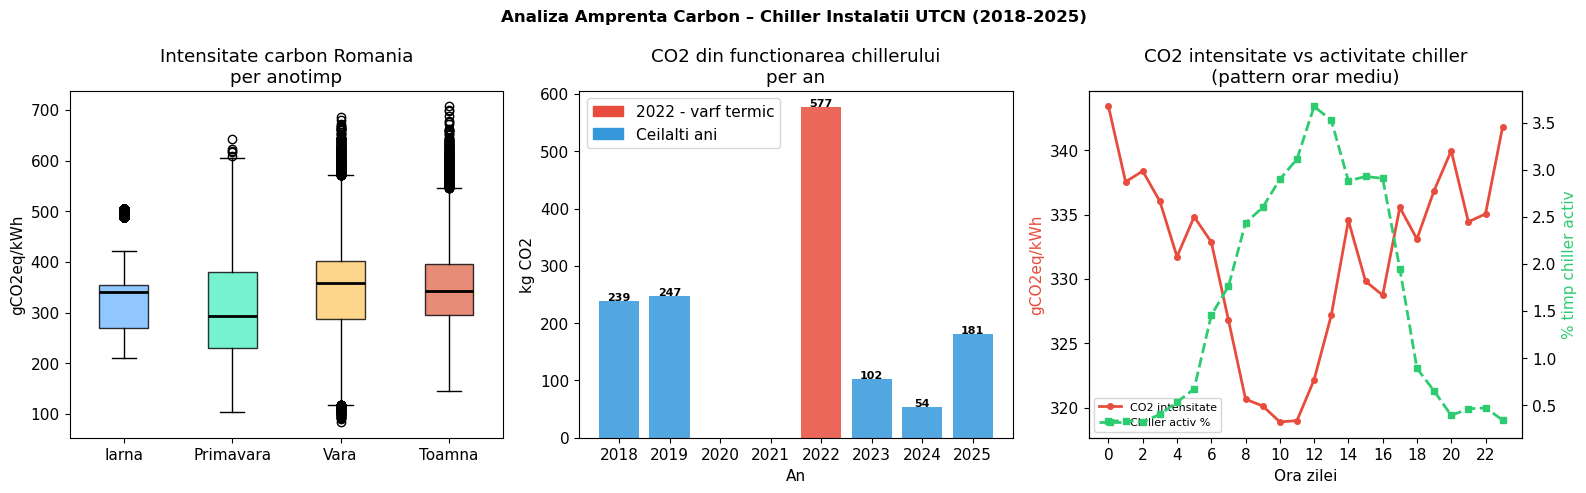

In [55]:
# ── Grafice Carbon Analysis ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. CO2 intensitate orara per anotimp (distributie)
if CARBON_OK:
    df_merged['Anotimp'] = df_merged['luna'].map({
        12:'Iarna',1:'Iarna',2:'Iarna',
        3:'Primavara',4:'Primavara',5:'Primavara',
        6:'Vara',7:'Vara',8:'Vara',
        9:'Toamna',10:'Toamna',11:'Toamna'
    })
    data_box = [df_merged.loc[df_merged['Anotimp']==s, 'co2_intensity'].dropna().values
                for s in ['Iarna','Primavara','Vara','Toamna']]
    bp = axes[0].boxplot(data_box, labels=['Iarna','Primavara','Vara','Toamna'],
                         patch_artist=True, medianprops=dict(color='black',linewidth=2))
    for patch, color in zip(bp['boxes'], ['#74b9ff','#55efc4','#fdcb6e','#e17055']):
        patch.set_facecolor(color); patch.set_alpha(0.8)
    axes[0].set_ylabel('gCO2eq/kWh')
    axes[0].set_title('Intensitate carbon Romania\nper anotimp')
else:
    co2_luni = {1:350,2:340,3:310,4:280,5:260,6:240,7:230,8:240,9:270,10:300,11:330,12:350}
    axes[0].bar(range(1,13), [co2_luni[m] for m in range(1,13)],
                color='steelblue', alpha=0.8)
    axes[0].set_xticks(range(1,13))
    axes[0].set_xticklabels(['Ian','Feb','Mar','Apr','Mai','Iun','Iul','Aug','Sep','Oct','Nov','Dec'],
                             rotation=30, fontsize=8)
    axes[0].set_ylabel('gCO2eq/kWh')
    axes[0].set_title('Intensitate carbon Romania\n(medii lunare estimate)')

# 2. CO2 chiller per an
ani_plot = yearly_co2[yearly_co2['an'].between(2018,2025)]
culori_ani = ['#e74c3c' if a==2022 else '#3498db' for a in ani_plot['an']]
bars = axes[1].bar(ani_plot['an'].astype(str), ani_plot['co2_chiller_kg'],
                   color=culori_ani, alpha=0.85)
for bar, val in zip(bars, ani_plot['co2_chiller_kg']):
    if val > 10:
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                     f'{val:.0f}', ha='center', fontsize=8, fontweight='bold')
axes[1].set_ylabel('kg CO2')
axes[1].set_xlabel('An')
axes[1].set_title('CO2 din functionarea chillerului\nper an')
axes[1].legend(handles=[
    mpatches.Patch(color='#e74c3c', label='2022 - varf termic'),
    mpatches.Patch(color='#3498db', label='Ceilalti ani')
])

# 3. Pattern orar CO2 vs chiller ON
if CARBON_OK:
    hourly_co2     = df_merged.groupby('ora')['co2_intensity'].mean()
    hourly_chiller = df_merged.groupby('ora')['ID_32_ON'].mean() * 100
    
    ax_co2  = axes[2]
    ax_chi  = ax_co2.twinx()
    
    l1 = ax_co2.plot(range(24), hourly_co2.values, color='#e74c3c',
                     linewidth=2, marker='o', markersize=4, label='CO2 intensitate')
    l2 = ax_chi.plot(range(24), hourly_chiller.values, color='#2ecc71',
                     linewidth=2, marker='s', markersize=4, linestyle='--', label='Chiller activ %')
    
    ax_co2.set_xlabel('Ora zilei')
    ax_co2.set_ylabel('gCO2eq/kWh', color='#e74c3c')
    ax_chi.set_ylabel('% timp chiller activ', color='#2ecc71')
    ax_co2.set_xticks(range(0,24,2))
    ax_co2.set_title('CO2 intensitate vs activitate chiller\n(pattern orar mediu)')
    
    lines = l1 + l2
    labels = [l.get_label() for l in lines]
    ax_co2.legend(lines, labels, fontsize=8)
else:
    axes[2].text(0.5, 0.5, 'Date orare CO2 indisponibile.\nSe folosesc medii lunare.',
                 ha='center', va='center', transform=axes[2].transAxes, fontsize=10)
    axes[2].set_title('Pattern orar CO2 vs chiller')

plt.suptitle('Analiza Amprenta Carbon – Chiller Instalatii UTCN (2018-2025)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [56]:
# ── Load Shifting Potential ───────────────────────────────────
# Identificam orele cu CO2 ridicat in care chilerul functioneaza
# si estimam ce s-ar economisi daca am muta consumul in ore verzi

if CARBON_OK:
    # Prag: ore cu CO2 > percentila 75 = "ore murdare"
    co2_p75 = df_merged['co2_intensity'].quantile(0.75)
    co2_p25 = df_merged['co2_intensity'].quantile(0.25)
    
    mask_ore_murdare = df_merged['co2_intensity'] > co2_p75
    mask_ore_verzi   = df_merged['co2_intensity'] < co2_p25
    mask_chiller_on  = df_merged['ID_32_ON'] == 1
    
    kwh_in_ore_murdare = df_merged.loc[mask_chiller_on & mask_ore_murdare, 'kwh'].sum()
    kwh_in_ore_verzi   = df_merged.loc[mask_chiller_on & mask_ore_verzi,   'kwh'].sum()
    kwh_total_chiller  = df_merged.loc[mask_chiller_on, 'kwh'].sum()
    
    co2_actual_kg     = df_merged.loc[mask_chiller_on, 'co2_kg'].sum()
    co2_if_shifted_kg = kwh_total_chiller * co2_p25 / 1000  # daca tot consumul ar fi in ore verzi
    co2_saving_kg     = co2_actual_kg - co2_if_shifted_kg
    
    print('=== Analiza Load Shifting Potential ===')
    print(f'Prag ore "murdare" (CO2 > P75): {co2_p75:.0f} gCO2eq/kWh')
    print(f'Prag ore "verzi"   (CO2 < P25): {co2_p25:.0f} gCO2eq/kWh')
    print()
    print(f'Chiller activ in ore murdare: {kwh_in_ore_murdare:.1f} kWh ({100*kwh_in_ore_murdare/kwh_total_chiller:.1f}%)')
    print(f'Chiller activ in ore verzi:   {kwh_in_ore_verzi:.1f} kWh ({100*kwh_in_ore_verzi/kwh_total_chiller:.1f}%)')
    print()
    print(f'CO2 actual (functionare reala):          {co2_actual_kg:.1f} kg')
    print(f'CO2 estimat daca tot consumul = ore verzi: {co2_if_shifted_kg:.1f} kg')
    print(f'Reducere CO2 potentiala prin load shifting: {co2_saving_kg:.1f} kg ({100*co2_saving_kg/co2_actual_kg:.1f}%)')
    print()
    print('Nota: Load shifting este posibil doar daca cladirea are inertie termica')
    print('suficienta (pre-racire in orele verzi). Propunem aceasta ca future work.')
else:
    print('Date orare CO2 indisponibile - load shifting nu poate fi calculat cu precizie.')
    print('Cu factorul mediu Romania (270 gCO2/kWh):')
    kwh_total = df_merged.loc[df_merged['ID_32_ON']==1, 'kwh'].sum()
    co2_total = kwh_total * 270 / 1000
    print(f'  CO2 total chiller (2018-2025): {co2_total:.1f} kg = {co2_total/1000:.2f} tone CO2')


=== Analiza Load Shifting Potential ===
Prag ore "murdare" (CO2 > P75): 383 gCO2eq/kWh
Prag ore "verzi"   (CO2 < P25): 271 gCO2eq/kWh

Chiller activ in ore murdare: 1158.8 kWh (27.4%)
Chiller activ in ore verzi:   984.3 kWh (23.3%)

CO2 actual (functionare reala):          1399.4 kg
CO2 estimat daca tot consumul = ore verzi: 1147.6 kg
Reducere CO2 potentiala prin load shifting: 251.9 kg (18.0%)

Nota: Load shifting este posibil doar daca cladirea are inertie termica
suficienta (pre-racire in orele verzi). Propunem aceasta ca future work.


---
## Secțiunea 13 – Senzor Virtual NILM


Dacă da, demonstrăm că **sub-contorizarea fizică nu mai este necesară**
dacă avem un model digital bun — aceasta este contribuția principală NILM.

**Model:** Random Forest Regressor
- **Input:** ID_31, temperatura, umiditate, Heat Index, ora, ziua săptămânii, luna
- **Output:** valoarea kW a ID_32 (consum chiller)
- **Train:** 2018-2022 | **Test:** 2023-2025 (validare pe date nevăzute)

**Metrici:** R², MAE, RMSE


In [57]:
# ── Pregatire features pentru Senzor Virtual ─────────────────
df_clean['kwh']     = df_clean['ID_32'] * 0.25
df_clean['an']      = df_clean['Date'].dt.year
df_clean['luna']    = df_clean['Date'].dt.month
df_clean['ora']     = df_clean['Date'].dt.hour
df_clean['zi_sapt'] = df_clean['Date'].dt.dayofweek

if 'heat_index' not in df_clean.columns:
    df_clean['heat_index'] = calculeaza_heat_index(
        df_clean['temp_C'].values, df_clean['humidity'].values
    )

# ── Lag features ──────────────────────────────────────────────
df_clean['ID_31_lag1']   = df_clean['ID_31'].shift(1)    # 15 minute in urma
df_clean['ID_31_lag4']   = df_clean['ID_31'].shift(4)    # 1 ora in urma
df_clean['ID_31_lag96']  = df_clean['ID_31'].shift(96)   # 24 ore in urma (acelasi moment ieri)
df_clean['ID_32_lag1']   = df_clean['ID_32'].shift(1)    # starea anterioara chiller
df_clean['ID_32_lag4']   = df_clean['ID_32'].shift(4)    # starea cu 1 ora in urma

# ── Rolling mean features ─────────────────────────────────────
df_clean['ID_31_roll4']  = df_clean['ID_31'].rolling(4).mean()   # medie 1 ora
df_clean['ID_31_roll16'] = df_clean['ID_31'].rolling(16).mean()  # medie 4 ore

# Eliminam randurile cu NaN din lag/rolling
df_clean_nilm = df_clean.dropna(subset=[
    'ID_31_lag1','ID_31_lag4','ID_31_lag96',
    'ID_32_lag1','ID_32_lag4',
    'ID_31_roll4','ID_31_roll16'
]).copy()

features_nilm = [
    'ID_31', 'ID_31_lag1', 'ID_31_lag4', 'ID_31_lag96',
    'ID_32_lag1', 'ID_32_lag4',
    'ID_31_roll4', 'ID_31_roll16',
    'temp_C', 'humidity', 'heat_index',
    'ora', 'zi_sapt', 'luna'
]
feature_labels_nilm = [
    'Consum general (kW)', 'ID_31 lag 15min', 'ID_31 lag 1h', 'ID_31 lag 24h',
    'Chiller lag 15min', 'Chiller lag 1h',
    'ID_31 medie 1h', 'ID_31 medie 4h',
    'Temperatura (C)', 'Umiditate (%)', 'Heat Index (C)',
    'Ora zilei', 'Ziua saptamanii', 'Luna'
]

X_nilm = df_clean_nilm[features_nilm].values
y_nilm = df_clean_nilm['ID_32'].values

# Split temporal: train 2018-2022, test 2023-2025
train_mask_nilm = df_clean_nilm['an'].between(2018, 2022)
test_mask_nilm  = df_clean_nilm['an'].between(2023, 2025)

X_train_n, y_train_n = X_nilm[train_mask_nilm], y_nilm[train_mask_nilm]
X_test_n,  y_test_n  = X_nilm[test_mask_nilm],  y_nilm[test_mask_nilm]

print(f'Train (2018-2022): {len(X_train_n):,} inregistrari')
print(f'Test  (2023-2025): {len(X_test_n):,} inregistrari')
print(f'Features: {len(features_nilm)} (original 7 + lag 5 + rolling 2)')
print()
print('Antrenare Random Forest + XGBoost...')

# ── Random Forest ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
rf_nilm = RandomForestRegressor(
    n_estimators=100, max_depth=15,
    min_samples_leaf=10, random_state=42, n_jobs=-1
)
rf_nilm.fit(X_train_n, y_train_n)
y_pred_nilm = rf_nilm.predict(X_test_n).clip(min=0)

r2   = r2_score(y_test_n, y_pred_nilm)
mae  = mean_absolute_error(y_test_n, y_pred_nilm)
rmse = np.sqrt(mean_squared_error(y_test_n, y_pred_nilm))

# ── XGBoost ───────────────────────────────────────────────────
from xgboost import XGBRegressor
xgb_nilm = XGBRegressor(
    n_estimators=200, max_depth=8,
    learning_rate=0.05, subsample=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_nilm.fit(X_train_n, y_train_n)
y_pred_xgb = xgb_nilm.predict(X_test_n).clip(min=0)

r2_xgb   = r2_score(y_test_n, y_pred_xgb)
mae_xgb  = mean_absolute_error(y_test_n, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_n, y_pred_xgb))

print()
print('=== Comparatie modele Senzor Virtual (Test 2023-2025) ===')
print(f'{"Model":<20} {"R²":>8} {"MAE (kW)":>10} {"RMSE (kW)":>10}')
print('-' * 52)
print(f'{"Random Forest":<20} {r2:>8.4f} {mae:>10.4f} {rmse:>10.4f}')
print(f'{"XGBoost":<20} {r2_xgb:>8.4f} {mae_xgb:>10.4f} {rmse_xgb:>10.4f}')
print()

best_model = 'XGBoost' if r2_xgb > r2 else 'Random Forest'
best_r2    = max(r2_xgb, r2)
print(f'Model mai bun: {best_model} (R²={best_r2:.4f})')
print()
print('Importanta features (Random Forest):')
for feat, imp in sorted(zip(feature_labels_nilm, rf_nilm.feature_importances_),
                         key=lambda x: x[1], reverse=True):
    bar = '█' * int(imp * 50)
    print(f'  {feat:<25}: {imp:.4f} {bar}')

Train (2018-2022): 131,656 inregistrari
Test  (2023-2025): 101,984 inregistrari
Features: 14 (original 7 + lag 5 + rolling 2)

Antrenare Random Forest + XGBoost...

=== Comparatie modele Senzor Virtual (Test 2023-2025) ===
Model                      R²   MAE (kW)  RMSE (kW)
----------------------------------------------------
Random Forest          0.8702     0.0692     0.2304
XGBoost                0.8668     0.0722     0.2334

Model mai bun: Random Forest (R²=0.8702)

Importanta features (Random Forest):
  Chiller lag 15min        : 0.4715 ███████████████████████
  Chiller lag 1h           : 0.2117 ██████████
  Consum general (kW)      : 0.2115 ██████████
  Temperatura (C)          : 0.0359 █
  Heat Index (C)           : 0.0327 █
  ID_31 lag 15min          : 0.0124 
  ID_31 medie 1h           : 0.0074 
  Luna                     : 0.0034 
  ID_31 medie 4h           : 0.0033 
  ID_31 lag 1h             : 0.0032 
  Ora zilei                : 0.0023 
  Umiditate (%)            : 0.0023 

Salvat: fig_25.png


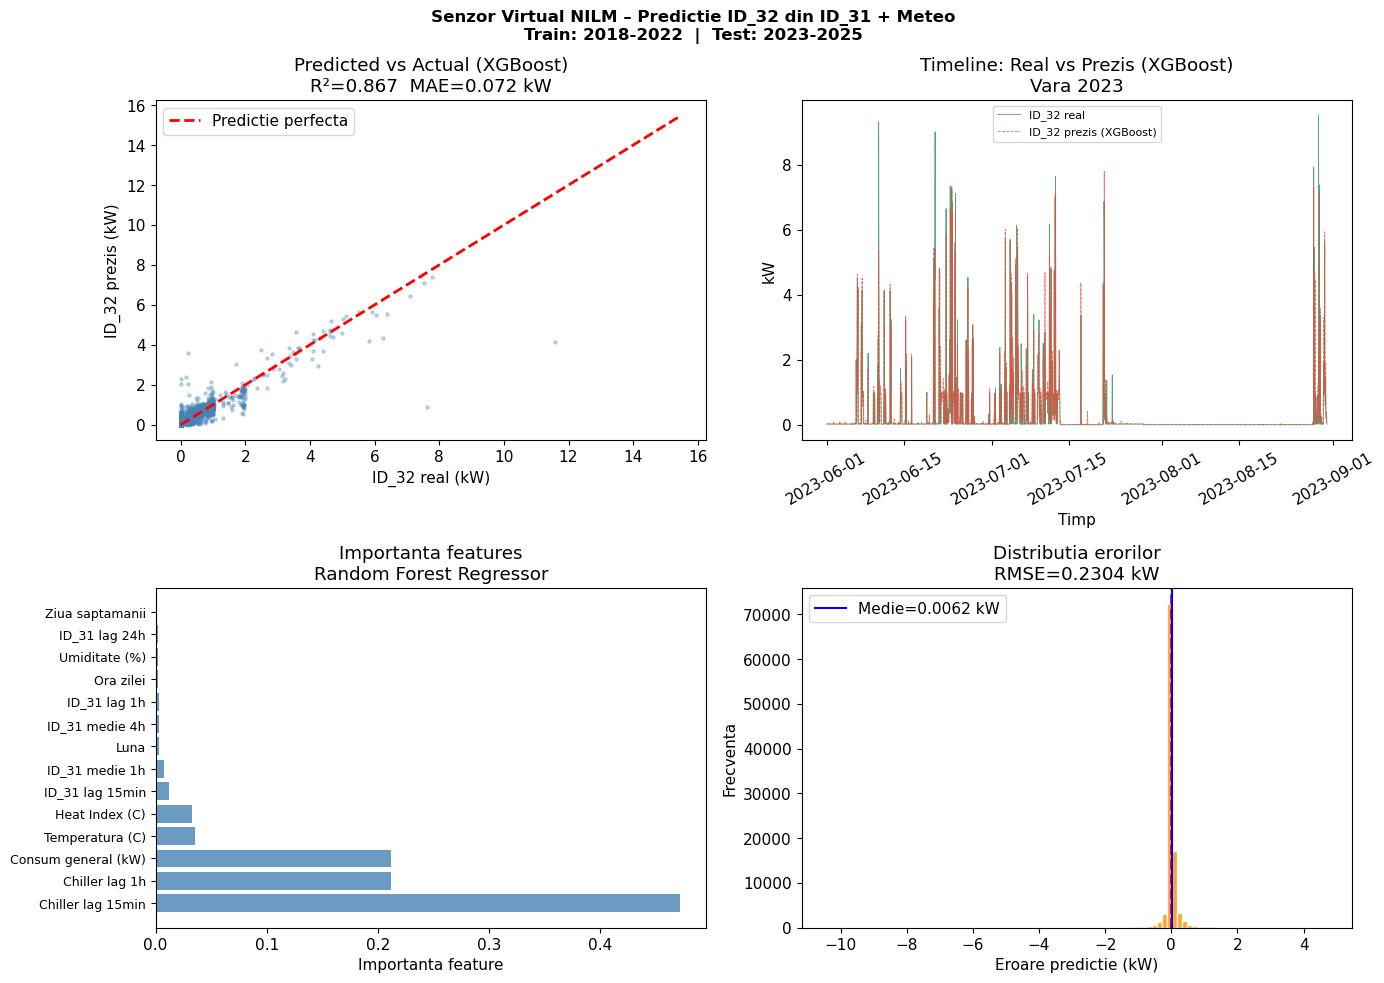

In [58]:
# ── Grafice Senzor Virtual ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Predicted vs Actual scatter (sample 5000 pt viteza)
# Cu asta:
idx_sample = np.random.choice(len(y_test_n), min(5000, len(y_test_n)), replace=False)
axes[0,0].scatter(y_test_n[idx_sample], y_pred_xgb[idx_sample],
                  alpha=0.3, s=5, color='steelblue')
max_val = max(y_test_n.max(), y_pred_nilm.max())
axes[0,0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Predictie perfecta')
axes[0,0].set_xlabel('ID_32 real (kW)')
axes[0,0].set_ylabel('ID_32 prezis (kW)')
axes[0,0].set_title(f'Predicted vs Actual (XGBoost)\nR²={r2_xgb:.3f}  MAE={mae_xgb:.3f} kW')
axes[0,0].legend()

# Panel 2: Timeline vara 2023
ZOOM_V = '2023-06-01'
ZOOM_E = '2023-08-31'

# Folosim df_clean_nilm care are indexul corect
dates_test  = df_clean_nilm.loc[test_mask_nilm, 'Date'].values
id32_test   = y_test_n
pred_test   = y_pred_xgb

# Filtram vara 2023 din test set
mz_v = (pd.to_datetime(dates_test) >= ZOOM_V) & (pd.to_datetime(dates_test) <= ZOOM_E)

dates_zoom = dates_test[mz_v]
real_zoom  = id32_test[mz_v]
pred_zoom  = pred_test[mz_v]

step = max(1, len(dates_zoom) // 2000)
axes[0,1].plot(dates_zoom[::step], real_zoom[::step],
               color='seagreen', linewidth=0.6, alpha=0.8, label='ID_32 real')
axes[0,1].plot(dates_zoom[::step], pred_zoom[::step],
               color='#e74c3c', linewidth=0.6, alpha=0.8,
               linestyle='--', label='ID_32 prezis (XGBoost)')
axes[0,1].set_ylabel('kW')
axes[0,1].set_xlabel('Timp')
axes[0,1].set_title(f'Timeline: Real vs Prezis (XGBoost)\nVara 2023')
axes[0,1].legend(fontsize=8)
axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(axes[0,1].xaxis.get_majorticklabels(), rotation=30)
# 3. Feature importance
feat_imp = sorted(zip(feature_labels_nilm, rf_nilm.feature_importances_),
                  key=lambda x: x[1], reverse=True)
labels_fi = [f[0] for f in feat_imp]
values_fi = [f[1] for f in feat_imp]
axes[1,0].barh(range(len(labels_fi)), values_fi, color='steelblue', alpha=0.8)
axes[1,0].set_yticks(range(len(labels_fi)))
axes[1,0].set_yticklabels(labels_fi, fontsize=9)
axes[1,0].set_xlabel('Importanta feature')
axes[1,0].set_title('Importanta features\nRandom Forest Regressor')

# 4. Distributia erorilor
erori = y_pred_nilm - y_test_n
axes[1,1].hist(erori, bins=100, color='darkorange', alpha=0.8, edgecolor='white')
axes[1,1].axvline(0, color='red', linewidth=2, linestyle='--')
axes[1,1].axvline(erori.mean(), color='blue', linewidth=1.5,
                   label=f'Medie={erori.mean():.4f} kW')
axes[1,1].set_xlabel('Eroare predictie (kW)')
axes[1,1].set_ylabel('Frecventa')
axes[1,1].set_title(f'Distributia erorilor\nRMSE={rmse:.4f} kW')
axes[1,1].legend()

plt.suptitle('Senzor Virtual NILM – Predictie ID_32 din ID_31 + Meteo\n'
             'Train: 2018-2022  |  Test: 2023-2025',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


=== Senzor Virtual: detectie ON/OFF chiller (Test 2023-2025) ===
Threshold aplicat: 2.0 kW

              precision    recall  f1-score   support

         OFF       1.00      1.00      1.00    100764
          ON       0.85      0.91      0.88      1220

    accuracy                           1.00    101984
   macro avg       0.93      0.95      0.94    101984
weighted avg       1.00      1.00      1.00    101984

Precision: 0.852
Recall:    0.911
F1-score:  0.880

Comparatie cu metodele anterioare (sec. 6):
  Threshold simplu (ID_31)      : P=0.039  R=0.990  F1=0.075
  SAX (ID_32)                   : P=0.022  R=0.840  F1=0.043
  Senzor Virtual (XGBoost)      : P=0.852  R=0.911  F1=0.880

ROC-AUC XGBoost virtual sensor: 0.997

Salvat: fig_27.png


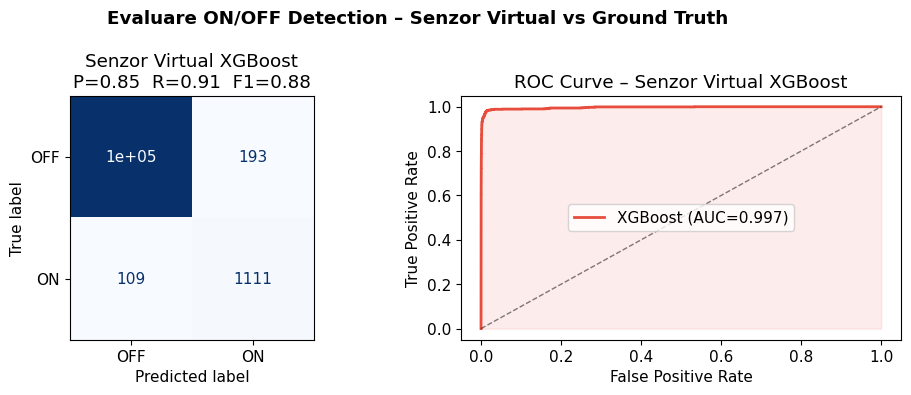

In [61]:
# ── Evaluare detectie ON/OFF din senzorul virtual ─────────────
THRESHOLD_VIRTUAL = THRESHOLD_ON  # 2.0 kW

y_pred_on_off = (y_pred_xgb   > THRESHOLD_VIRTUAL).astype(int)
y_true_on_off = (y_test_n     > THRESHOLD_VIRTUAL).astype(int)

p_v = precision_score(y_true_on_off, y_pred_on_off, zero_division=0)
r_v = recall_score(y_true_on_off,    y_pred_on_off, zero_division=0)
f_v = f1_score(y_true_on_off,        y_pred_on_off, zero_division=0)

print('=== Senzor Virtual: detectie ON/OFF chiller (Test 2023-2025) ===')
print(f'Threshold aplicat: {THRESHOLD_VIRTUAL} kW')
print()
print(classification_report(y_true_on_off, y_pred_on_off, target_names=['OFF','ON']))
print(f'Precision: {p_v:.3f}')
print(f'Recall:    {r_v:.3f}')
print(f'F1-score:  {f_v:.3f}')
print()
print('Comparatie cu metodele anterioare (sec. 6):')
for name, (p,r,f) in results_metrics.items():
    print(f'  {name:<30}: P={p:.3f}  R={r:.3f}  F1={f:.3f}')
print(f'  {"Senzor Virtual (XGBoost)":<30}: P={p_v:.3f}  R={r_v:.3f}  F1={f_v:.3f}')
print()

# ROC-AUC
y_prob_xgb_on = (y_pred_xgb - y_pred_xgb.min()) / (y_pred_xgb.max() - y_pred_xgb.min())
auc_xgb = roc_auc_score(y_true_on_off, y_prob_xgb_on)
print(f'ROC-AUC XGBoost virtual sensor: {auc_xgb:.3f}')
print()

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm_v = confusion_matrix(y_true_on_off, y_pred_on_off)
ConfusionMatrixDisplay(cm_v, display_labels=['OFF','ON']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Senzor Virtual XGBoost\nP={p_v:.2f}  R={r_v:.2f}  F1={f_v:.2f}')

# ROC curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_true_on_off, y_prob_xgb_on)
axes[1].plot(fpr_xgb, tpr_xgb, color='#e74c3c', linewidth=2,
             label=f'XGBoost (AUC={auc_xgb:.3f})')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5)
axes[1].fill_between(fpr_xgb, tpr_xgb, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve – Senzor Virtual XGBoost')
axes[1].legend()

plt.suptitle('Evaluare ON/OFF Detection – Senzor Virtual vs Ground Truth',
             fontweight='bold')
plt.tight_layout()
plt.show()

In [62]:
# ── Rezumat final complet ─────────────────────────────────────
print('=' * 65)
print('REZUMAT COMPLET – Analiza Chiller Instalatii UTCN (2017-2026)')
print('=' * 65)
print(f'Total inregistrari:          {len(df):,}')
print(f'Interval:                    {df["Date"].min().date()} -> {df["Date"].max().date()}')
print()
print('── Detecție outlieri ID_32 ────────────────────────────────')
print(f'  Fizici (>50 kW):           {mask_phys_32.sum():>6}')
print(f'  Frozen sensor:             {mask_frozen_32.sum():>6}')
print(f'  Contextuali (temp<15C):    {mask_context_32.sum():>6}')
print(f'  TOTAL:                     {mask_all_bad_32.sum():>6} ({100*mask_all_bad_32.sum()/len(df):.2f}%)')
print()
print('── Energie risipita prin erori senzor ─────────────────────')
print(f'  kWh raportat eronat (frozen sensor): {kwh_frozen_eronat:.1f} kWh')
print(f'  CO2 asociat:                         {co2_frozen_kg:.1f} kg CO2')
print()
print('── Profil sezonier ────────────────────────────────────────')
for s, p in zip(order_sez, pct_activ):
    print(f'  {s:<12}: {p:.1f}% timp activ')
print()
print('── CDD Analysis ───────────────────────────────────────────')
print(f'  Pearson r CDD vs kWh (fara anomalii): {r_temp_no24:.3f}')
print(f'  Pearson r CDD-HI vs kWh (fara anomalii): {r_hi_no24:.3f}')
print()
print('── Logistic Regression (sec. 11) ──────────────────────────')
for name, (p,r,f) in results_metrics.items():
    print(f'  {name:<30}: F1={f:.3f}')
print(f'  ROC-AUC:                  {auc:.3f}')
print()
print('── Senzor Virtual NILM (sec. 13) ──────────────────────────')
print(f'  R²:   {r2:.4f}')
print(f'  MAE:  {mae:.4f} kW')
print(f'  RMSE: {rmse:.4f} kW')
print(f'  F1 detectie ON/OFF:      {f_v:.3f}')
print()
print('── Carbon Intensity ────────────────────────────────────────')
print(f'  CO2 total chiller (2018-2025): {total_co2_chiller:.1f} kg = {total_co2_chiller/1000:.2f} tone')
if CARBON_OK:
    print(f'  Reducere CO2 potentiala (load shifting): {co2_saving_kg:.1f} kg ({100*co2_saving_kg/co2_actual_kg:.1f}%)')
print()
print(f'  Logistic Regression: P={p_lr:.3f}  R={r_lr:.3f}  F1={f1_lr:.3f}')
print(f'  ROC-AUC Logistic Regression: {auc:.3f}')
print(f'  ROC-AUC Senzor Virtual XGBoost: {auc_xgb:.3f}')

print('=' * 65)


REZUMAT COMPLET – Analiza Chiller Instalatii UTCN (2017-2026)
Total inregistrari:          239,447
Interval:                    2017-12-02 -> 2026-01-31

── Detecție outlieri ID_32 ────────────────────────────────
  Fizici (>50 kW):                6
  Frozen sensor:               1230
  Contextuali (temp<15C):       513
  TOTAL:                       1749 (0.73%)

── Energie risipita prin erori senzor ─────────────────────
  kWh raportat eronat (frozen sensor): 606.1 kWh
  CO2 asociat:                         163.6 kg CO2

── Profil sezonier ────────────────────────────────────────
  Iarnă       : 0.0% timp activ
  Primăvară   : 0.6% timp activ
  Vară        : 5.4% timp activ
  Toamnă      : 0.4% timp activ

── CDD Analysis ───────────────────────────────────────────
  Pearson r CDD vs kWh (fara anomalii): 0.789
  Pearson r CDD-HI vs kWh (fara anomalii): 0.745

── Logistic Regression (sec. 11) ──────────────────────────
  Threshold simplu (ID_31)      : F1=0.075
  SAX (ID_32)          